# V03 Appendiks CT Sınıflandırma: 5-Fold Stratified CV + SegFormer 3D

Bu notebook, **V03 native canvas** dataset varyasyonu için hasta-bazlı binary sınıflandırma yapar.

- **Sınıf 0:** appendisit
- **Sınıf 1:** müsinöz

Kullanılan dataset varyasyonu:

```text
v03_native_canvas_128_D32
```

V03 mantığı:

```text
Her ROI kesiti için appendiks/ROI merkezi 128×128 native canvas merkezine alınır.
Interpolation yapılmaz.
128×128 alandaki CT piksel değerleri orijinal çözünürlükte korunur.
```

Beklenen H5 image formatı:

```text
/image: [D, H, W, C] = [32, 128, 128, 1]
/mask : [D, H, W]
```

PyTorch input formatı:

```text
[C, D, H, W] = [1, 32, 128, 128]
```

Notebook çıktıları:

```text
manifest CSV
5-fold split CSV
her fold için model checkpoint
her fold için prediction CSV
her fold için confusion matrix PNG/CSV
her fold için ROC ve PR eğrileri
model bazında out-of-fold prediction CSV
model bazında aggregate confusion matrix
SegFormer 3D analizi
opsiyonel Grad-CAM örnekleri
```


## 0. Kurulum notu

Gerekli paketler:

```bash
pip install torch torchvision torchaudio h5py pandas numpy scikit-learn matplotlib tqdm
```

CUDA varsa PyTorch'u kendi sisteminize uygun CUDA sürümüyle kurmanız gerekir.


In [1]:
# ============================================================
# 1) Imports
# ============================================================

from pathlib import Path
import os
import json
import random
import math
import time
import copy
import warnings

import numpy as np
import pandas as pd
import h5py

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
)

import matplotlib.pyplot as plt
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("cuda device:", torch.cuda.get_device_name(0))


torch: 2.10.0+cu128
cuda available: True
cuda device: NVIDIA GeForce RTX 5090


In [2]:
# ============================================================
# 2) Config
# ============================================================

CONFIG = {
    # V03 klasörleri
    "appendicitis_v03_dir": r"/home/zera/Downloads/Appendiks varyasyon3 DS-20260713T105239Z-2-001/Appendiks varyasyon3 DS/Appendisit/v03_native_canvas_128_D32",
    "mucinous_v03_dir":     r"/home/zera/Downloads/Appendiks varyasyon3 DS-20260713T105239Z-2-001/Appendiks varyasyon3 DS/Musinoz/v03_native_canvas_128_D32",

    # Çıktı klasörü
    "output_dir": r"/home/zera/Downloads/Appendiks varyasyon3 DS-20260713T105239Z-2-001/Appendiks varyasyon3 DS/segformer/experiments",

    # CV
    "n_splits": 5,
    "random_seed": 42,

    # Input
    "expected_D": 32,
    "expected_H": 128,
    "expected_W": 128,
    "expected_C": 1,

    # Eğitim
    "num_epochs": 100,
    "batch_size": 8,
    "num_workers": 0,   # Linux ortamında 4 veya daha fazla yapılabilir
    "learning_rate": 1e-4,
    "weight_decay": 1e-4,
    "early_stopping_patience": 20,
    "use_amp": True,

    # Augmentasyon
    "augment_train": True,
    "xy_flip_p": 0.50,
    "intensity_jitter_p": 0.50,
    "noise_p": 0.30,

    # Threshold
    "default_threshold": 0.50,

    # Modeller
    "models_to_run": ["segformer3d"],

    # Debug/deneme için epoch veya fold sınırlandırmak isterseniz:
    "limit_folds": None,      # örn. 1 yaparsanız sadece ilk fold
    "limit_epochs": None,     # örn. 2 yaparsanız hızlı test
}

OUTPUT_DIR = Path(CONFIG["output_dir"])
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

with open(OUTPUT_DIR / "config.json", "w", encoding="utf-8") as f:
    json.dump(CONFIG, f, indent=2, ensure_ascii=False)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)
print("OUTPUT_DIR:", OUTPUT_DIR)


DEVICE: cuda
OUTPUT_DIR: /home/zera/Downloads/Appendiks varyasyon3 DS-20260713T105239Z-2-001/Appendiks varyasyon3 DS/segformer/experiments


In [3]:
# ============================================================
# 3) Reproducibility
# ============================================================

def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Daha deterministik çalışma için:
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

seed_everything(CONFIG["random_seed"])


In [4]:
# ============================================================
# 4) Manifest oluşturma ve H5 sanity check
# ============================================================

def safe_read_h5_shape_and_label(h5_path: Path):
    """H5 dosyasını minimal açıp image shape ve label kontrolü yapar."""
    try:
        with h5py.File(h5_path, "r") as f:
            if "image" not in f:
                return None, None, "missing /image"
            image_shape = tuple(f["image"].shape)

            label = None
            if "label" in f:
                label_arr = np.array(f["label"])
                label = int(label_arr.reshape(-1)[0])
            elif "label" in f.attrs:
                label = int(f.attrs["label"])

            return image_shape, label, None

    except Exception as e:
        return None, None, str(e)


def build_manifest(config):
    append_dir = Path(config["appendicitis_v03_dir"])
    muc_dir = Path(config["mucinous_v03_dir"])

    rows = []

    for h5_path in sorted(append_dir.glob("*.h5")):
        image_shape, h5_label, err = safe_read_h5_shape_and_label(h5_path)
        rows.append({
            "patient_id": h5_path.stem,
            "h5_path": str(h5_path),
            "label": 0,
            "label_name": "appendicitis",
            "image_shape": str(image_shape),
            "h5_label": h5_label,
            "read_error": err,
        })

    for h5_path in sorted(muc_dir.glob("*.h5")):
        image_shape, h5_label, err = safe_read_h5_shape_and_label(h5_path)
        rows.append({
            "patient_id": h5_path.stem,
            "h5_path": str(h5_path),
            "label": 1,
            "label_name": "mucinous",
            "image_shape": str(image_shape),
            "h5_label": h5_label,
            "read_error": err,
        })

    df = pd.DataFrame(rows)
    if df.empty:
        raise RuntimeError("Manifest boş. V03 klasör yollarını kontrol edin.")

    # H5 okuma hatası olanları çıkar
    bad = df[df["read_error"].notna()]
    if len(bad) > 0:
        print("Okunamayan H5 dosyaları:")
        display(bad)
        df = df[df["read_error"].isna()].copy()

    # H5 label ile folder label uyumu kontrolü
    mismatch = df[(df["h5_label"].notna()) & (df["h5_label"] != df["label"])]
    if len(mismatch) > 0:
        print("UYARI: H5 label ile manifest label uyuşmuyor:")
        display(mismatch)

    df = df.reset_index(drop=True)

    # duplicate patient_id var mı?
    dup = df[df.duplicated("patient_id", keep=False)].sort_values("patient_id")
    if len(dup) > 0:
        print("UYARI: Aynı patient_id birden fazla dosyada görünüyor.")
        print("Bu gerçek aynı hasta ise leakage riski olabilir; kontrol edin.")
        display(dup)

    return df


manifest_df = build_manifest(CONFIG)

print("Toplam hasta:", len(manifest_df))
print(manifest_df["label_name"].value_counts())
display(manifest_df.head())

manifest_path = OUTPUT_DIR / "v03_manifest_all.csv"
manifest_df.to_csv(manifest_path, index=False)
print("Manifest kaydedildi:", manifest_path)


UYARI: Aynı patient_id birden fazla dosyada görünüyor.
Bu gerçek aynı hasta ise leakage riski olabilir; kontrol edin.


,patient_id,h5_path,label,label_name,image_shape,h5_label,read_error
61,iman_tugce,/home/zera/Downloads/Appendiks varyasyon3 DS-2...,0,appendicitis,"(32, 128, 128, 1)",0,None
195,iman_tugce,/home/zera/Downloads/Appendiks varyasyon3 DS-2...,1,mucinous,"(32, 128, 128, 1)",1,None


Toplam hasta: 244
label_name
appendicitis    127
mucinous        117
Name: count, dtype: int64


,patient_id,h5_path,label,label_name,image_shape,h5_label,read_error
0,acis_batuhan,/home/zera/Downloads/Appendiks varyasyon3 DS-2...,0,appendicitis,"(32, 128, 128, 1)",0,None
1,adiyaman_batuhan,/home/zera/Downloads/Appendiks varyasyon3 DS-2...,0,appendicitis,"(32, 128, 128, 1)",0,None
2,agca_ozlem,/home/zera/Downloads/Appendiks varyasyon3 DS-2...,0,appendicitis,"(32, 128, 128, 1)",0,None
3,akbulut_musa,/home/zera/Downloads/Appendiks varyasyon3 DS-2...,0,appendicitis,"(32, 128, 128, 1)",0,None
4,akcan_gül,/home/zera/Downloads/Appendiks varyasyon3 DS-2...,0,appendicitis,"(32, 128, 128, 1)",0,None


Manifest kaydedildi: /home/zera/Downloads/Appendiks varyasyon3 DS-20260713T105239Z-2-001/Appendiks varyasyon3 DS/segformer/experiments/v03_manifest_all.csv


patient_id: acis_batuhan
path: /home/zera/Downloads/Appendiks varyasyon3 DS-20260713T105239Z-2-001/Appendiks varyasyon3 DS/Appendisit/v03_native_canvas_128_D32/acis_batuhan.h5
image DHWC: (32, 128, 128, 1) float32 0.0 1.0
label: 0 appendicitis
attrs keys: ['center_slot', 'channel_names', 'dicom_sort_mode', 'dropped_after', 'dropped_before', 'hu_clip', 'label', 'label_name', 'mask_flip_z', 'mask_load_transform'] ...


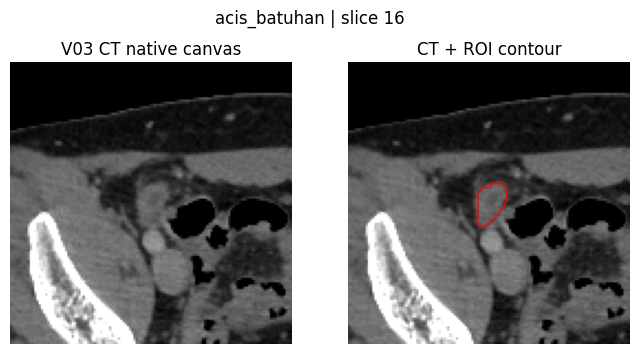

In [5]:
# ============================================================
# 5) H5 shape conversion ve tek örnek kontrolü
# ============================================================

def ensure_dhwc(image: np.ndarray, expected_D=32, expected_H=128, expected_W=128, expected_C=1):
    """
    V005 H5 dosyalarında Python/h5py ile beklenen shape [D,H,W,C].
    Single-channel V03 için bazen [D,H,W] veya eski/ters shape'ler görülebilir.
    Bu fonksiyon çıktı olarak her zaman [D,H,W,C] döndürür.
    """
    image = np.asarray(image)

    if image.ndim == 4:
        # Beklenen: [D,H,W,C]
        if image.shape == (expected_D, expected_H, expected_W, expected_C):
            return image

        # Olası eski/ters: [C,W,H,D]
        if image.shape == (expected_C, expected_W, expected_H, expected_D):
            return np.transpose(image, (3, 2, 1, 0))

        # Olası: [C,D,H,W]
        if image.shape == (expected_C, expected_D, expected_H, expected_W):
            return np.transpose(image, (1, 2, 3, 0))

        # Tek kanal ama kanal boyutu farklı konumdaysa
        if expected_C == 1 and image.shape[-1] == 1 and image.shape[:3] == (expected_D, expected_H, expected_W):
            return image

    if image.ndim == 3 and expected_C == 1:
        # [D,H,W]
        if image.shape == (expected_D, expected_H, expected_W):
            return image[..., None]

        # [H,W,D]
        if image.shape == (expected_H, expected_W, expected_D):
            return np.transpose(image, (2, 0, 1))[..., None]

        # [W,H,D]
        if image.shape == (expected_W, expected_H, expected_D):
            return np.transpose(image, (2, 1, 0))[..., None]

    raise ValueError(f"Beklenmeyen image shape: {image.shape}")


def ensure_mask_dhw(mask: np.ndarray, expected_D=32, expected_H=128, expected_W=128):
    mask = np.asarray(mask)

    if mask.ndim == 3:
        if mask.shape == (expected_D, expected_H, expected_W):
            return mask
        if mask.shape == (expected_H, expected_W, expected_D):
            return np.transpose(mask, (2, 0, 1))
        if mask.shape == (expected_W, expected_H, expected_D):
            return np.transpose(mask, (2, 1, 0))

    raise ValueError(f"Beklenmeyen mask shape: {mask.shape}")


def inspect_one_sample(df, idx=0):
    row = df.iloc[idx]
    with h5py.File(row["h5_path"], "r") as f:
        image = f["image"][:]
        mask = f["mask"][:] if "mask" in f else None
        label = int(np.array(f["label"]).reshape(-1)[0]) if "label" in f else int(row["label"])
        attrs = dict(f.attrs)

    image = ensure_dhwc(
        image,
        expected_D=CONFIG["expected_D"],
        expected_H=CONFIG["expected_H"],
        expected_W=CONFIG["expected_W"],
        expected_C=CONFIG["expected_C"],
    )
    print("patient_id:", row["patient_id"])
    print("path:", row["h5_path"])
    print("image DHWC:", image.shape, image.dtype, float(image.min()), float(image.max()))
    print("label:", label, row["label_name"])
    print("attrs keys:", list(attrs.keys())[:10], "...")

    D = image.shape[0]
    k = D // 2

    if mask is not None:
        mask = ensure_mask_dhw(mask, CONFIG["expected_D"], CONFIG["expected_H"], CONFIG["expected_W"])
        fig, axes = plt.subplots(1, 2, figsize=(8, 4))
        axes[0].imshow(image[k, :, :, 0], cmap="gray")
        axes[0].set_title("V03 CT native canvas")
        axes[0].axis("off")

        axes[1].imshow(image[k, :, :, 0], cmap="gray")
        axes[1].contour(mask[k] > 0, levels=[0.5], colors="r", linewidths=1)
        axes[1].set_title("CT + ROI contour")
        axes[1].axis("off")
        plt.suptitle(f"{row['patient_id']} | slice {k}")
        plt.show()
    else:
        plt.figure(figsize=(4, 4))
        plt.imshow(image[k, :, :, 0], cmap="gray")
        plt.title(f"{row['patient_id']} | slice {k}")
        plt.axis("off")
        plt.show()


inspect_one_sample(manifest_df, idx=0)


In [6]:
# ============================================================
# 6) Dataset ve augmentasyon
# ============================================================

class AppendixH5Dataset(Dataset):
    def __init__(self, dataframe: pd.DataFrame, augment: bool = False, config=None):
        self.df = dataframe.reset_index(drop=True).copy()
        self.augment = augment
        self.config = config if config is not None else CONFIG

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        h5_path = row["h5_path"]

        with h5py.File(h5_path, "r") as f:
            image = f["image"][:]  # [D,H,W,C] beklenir
            if "label" in f:
                label = int(np.array(f["label"]).reshape(-1)[0])
            else:
                label = int(row["label"])

            valid_z = f["valid_z"][:] if "valid_z" in f else np.ones((self.config["expected_D"],), dtype=np.uint8)

        image = ensure_dhwc(
            image,
            expected_D=self.config["expected_D"],
            expected_H=self.config["expected_H"],
            expected_W=self.config["expected_W"],
            expected_C=self.config["expected_C"],
        ).astype(np.float32)

        # [D,H,W,C] -> [C,D,H,W]
        image = np.transpose(image, (3, 0, 1, 2)).copy()

        if self.augment:
            image = self.apply_augmentations(image)

        x = torch.from_numpy(image).float()
        y = torch.tensor(label, dtype=torch.long)

        return {
            "image": x,
            "label": y,
            "patient_id": row["patient_id"],
            "h5_path": h5_path,
            "valid_z": torch.from_numpy(valid_z.astype(np.float32)),
        }

    def apply_augmentations(self, image):
        """
        image: [C,D,H,W]
        V03:
          C0 = native 128x128 CT crop

        Dikkat:
        - V03 interpolation yapmadan native CT crop verdiği için augmentasyonu hafif tutuyoruz.
        - Sadece x-y flip, hafif intensity jitter ve hafif gaussian noise kullanılır.
        """
        cfg = self.config

        # Left-right flip: W axis
        if np.random.rand() < cfg["xy_flip_p"]:
            image = image[:, :, :, ::-1].copy()

        # Anterior-posterior flip: H axis
        if np.random.rand() < cfg["xy_flip_p"]:
            image = image[:, :, ::-1, :].copy()

        # CT kanalına hafif intensity jitter
        if np.random.rand() < cfg["intensity_jitter_p"]:
            scale = np.random.uniform(0.95, 1.05)
            shift = np.random.uniform(-0.03, 0.03)
            image[0] = np.clip(image[0] * scale + shift, 0.0, 1.0)

        # CT kanalına hafif gaussian noise
        if np.random.rand() < cfg["noise_p"]:
            noise = np.random.normal(0, 0.01, size=image[0].shape).astype(np.float32)
            image[0] = np.clip(image[0] + noise, 0.0, 1.0)

        return image


# Batch testi
tmp_ds = AppendixH5Dataset(manifest_df.iloc[:min(4, len(manifest_df))], augment=True, config=CONFIG)
tmp_loader = DataLoader(tmp_ds, batch_size=2, shuffle=False, num_workers=4)

batch = next(iter(tmp_loader))
print("batch image:", batch["image"].shape)  # [B,1,32,128,128]
print("batch label:", batch["label"])


batch image: torch.Size([2, 1, 32, 128, 128])
batch label: tensor([0, 0])


In [7]:
# ============================================================
# Model: SegFormer3D-MSCA (Multi-Scale Context Attention)
# Makale (Q1/Q2) Kalitesi İçin Özelleştirilmiş Mimari
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F

class OverlapPatchEmbed3D(nn.Module):
    def __init__(self, in_channels, embed_dim, patch_size=3, stride=2, padding=1):
        super().__init__()
        self.proj = nn.Conv3d(in_channels, embed_dim, kernel_size=patch_size, stride=stride, padding=padding)
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, x):
        x = self.proj(x)
        B, C, D, H, W = x.shape
        x = x.flatten(2).transpose(1, 2)
        x = self.norm(x)
        x = x.transpose(1, 2).reshape(B, C, D, H, W)
        return x

class EfficientSelfAttention3D(nn.Module):
    def __init__(self, dim, num_heads=8, sr_ratio=1):
        super().__init__()
        self.num_heads = num_heads
        head_dim = dim // num_heads
        self.scale = head_dim ** -0.5

        self.q = nn.Linear(dim, dim)
        self.kv = nn.Linear(dim, dim * 2)
        self.proj = nn.Linear(dim, dim)

        self.sr_ratio = sr_ratio
        if sr_ratio > 1:
            self.sr = nn.Conv3d(dim, dim, kernel_size=sr_ratio, stride=sr_ratio)
            self.norm = nn.LayerNorm(dim)

    def forward(self, x):
        B, C, D, H, W = x.shape
        N = D * H * W
        x_flat = x.flatten(2).transpose(1, 2)

        q = self.q(x_flat).reshape(B, N, self.num_heads, C // self.num_heads).permute(0, 2, 1, 3)

        if self.sr_ratio > 1:
            x_ = self.sr(x).flatten(2).transpose(1, 2)
            x_ = self.norm(x_)
            kv = self.kv(x_).reshape(B, -1, 2, self.num_heads, C // self.num_heads).permute(2, 0, 3, 1, 4)
        else:
            kv = self.kv(x_flat).reshape(B, -1, 2, self.num_heads, C // self.num_heads).permute(2, 0, 3, 1, 4)
        
        k, v = kv[0], kv[1]

        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)

        out = (attn @ v).transpose(1, 2).reshape(B, N, C)
        out = self.proj(out)
        out = out.transpose(1, 2).reshape(B, C, D, H, W)
        return out

class MixFFN3D(nn.Module):
    def __init__(self, in_features, hidden_features):
        super().__init__()
        self.fc1 = nn.Conv3d(in_features, hidden_features, 1)
        self.dwconv = nn.Conv3d(hidden_features, hidden_features, 3, 1, 1, groups=hidden_features)
        self.fc2 = nn.Conv3d(hidden_features, in_features, 1)
        self.act = nn.GELU()

    def forward(self, x):
        x = self.fc1(x)
        x = self.dwconv(x)
        x = self.act(x)
        x = self.fc2(x)
        return x

class SegformerBlock3D(nn.Module):
    def __init__(self, dim, num_heads, sr_ratio):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = EfficientSelfAttention3D(dim, num_heads, sr_ratio)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = MixFFN3D(dim, dim * 4)

    def forward(self, x):
        B, C, D, H, W = x.shape
        x_flat = x.flatten(2).transpose(1, 2)
        norm1_x = self.norm1(x_flat).transpose(1, 2).reshape(B, C, D, H, W)
        
        x = x + self.attn(norm1_x)
        
        x_flat2 = x.flatten(2).transpose(1, 2)
        norm2_x = self.norm2(x_flat2).transpose(1, 2).reshape(B, C, D, H, W)
        
        x = x + self.mlp(norm2_x)
        return x

# YENİ MODÜL: 3D Spatial-Channel Attention (CBAM-3D)
class CBAM3D(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        # Channel Attention
        self.avg_pool = nn.AdaptiveAvgPool3d(1)
        self.max_pool = nn.AdaptiveMaxPool3d(1)
        self.fc = nn.Sequential(
            nn.Conv3d(channels, channels // reduction, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv3d(channels // reduction, channels, 1, bias=False))
        self.sigmoid_channel = nn.Sigmoid()
        
        # Spatial Attention
        self.conv_spatial = nn.Conv3d(2, 1, kernel_size=7, padding=3, bias=False)
        self.sigmoid_spatial = nn.Sigmoid()

    def forward(self, x):
        # Channel Attention
        avg_out = self.fc(self.avg_pool(x))
        max_out = self.fc(self.max_pool(x))
        channel_att = self.sigmoid_channel(avg_out + max_out)
        x = x * channel_att
        
        # Spatial Attention
        avg_spatial = torch.mean(x, dim=1, keepdim=True)
        max_spatial, _ = torch.max(x, dim=1, keepdim=True)
        spatial_cat = torch.cat([avg_spatial, max_spatial], dim=1)
        spatial_att = self.sigmoid_spatial(self.conv_spatial(spatial_cat))
        x = x * spatial_att
        return x

class SegFormer3DClassifier(nn.Module):
    """
    Makale İçin Geliştirilmiş Mimari (SegFormer3D-MSCA)
    1. Multi-Scale Feature Fusion (MSF): Sadece son katmanı değil, ara katmanları da birleştirir.
    2. CBAM-3D (Context Attention): En derin özniteliklerde uzamsal ve kanalsal dikkat mekanizması uygular.
    3. Gelişmiş MLP Sınıflandırıcı: Dropout ve Batch Normalization ile güçlendirilmiş head.
    """
    def __init__(self, in_channels=1, num_classes=2):
        super().__init__()
        embed_dims = [16, 32, 64, 128] # Model küçültüldü (Tiny-SegFormer)
        num_heads = [1, 2, 4, 8]
        sr_ratios = [4, 2, 2, 1]
        
        self.patch_embed1 = OverlapPatchEmbed3D(in_channels, embed_dims[0], patch_size=7, stride=2, padding=3)
        self.block1 = nn.Sequential(*[SegformerBlock3D(embed_dims[0], num_heads[0], sr_ratios[0]) for _ in range(2)])
        
        self.patch_embed2 = OverlapPatchEmbed3D(embed_dims[0], embed_dims[1], patch_size=3, stride=2, padding=1)
        self.block2 = nn.Sequential(*[SegformerBlock3D(embed_dims[1], num_heads[1], sr_ratios[1]) for _ in range(2)])
        
        self.patch_embed3 = OverlapPatchEmbed3D(embed_dims[1], embed_dims[2], patch_size=3, stride=2, padding=1)
        self.block3 = nn.Sequential(*[SegformerBlock3D(embed_dims[2], num_heads[2], sr_ratios[2]) for _ in range(2)])
        
        self.patch_embed4 = OverlapPatchEmbed3D(embed_dims[2], embed_dims[3], patch_size=3, stride=2, padding=1)
        self.block4 = nn.Sequential(*[SegformerBlock3D(embed_dims[3], num_heads[3], sr_ratios[3]) for _ in range(2)])
        
        # YENİ: CBAM 3D Dikkat Mekanizması
        self.cbam = CBAM3D(embed_dims[3])
        
        self.pool = nn.AdaptiveAvgPool3d(1)
        
        # YENİ: Multi-Scale Fusion Head (Stage 3 ve Stage 4 birleşimi)
        fusion_dim = embed_dims[2] + embed_dims[3] 
        self.fc = nn.Sequential(
            nn.Linear(fusion_dim, 128),
            nn.LayerNorm(128),
            nn.GELU(),
            nn.Dropout(0.6),
            nn.Linear(128, num_classes)
        )
    def forward(self, x):
        # Stage 1
        x = self.patch_embed1(x)
        x = self.block1(x)
        
        # Stage 2
        x = self.patch_embed2(x)
        x = self.block2(x)
        
        # Stage 3
        x = self.patch_embed3(x)
        x3 = self.block3(x)
        
        # Stage 4
        x = self.patch_embed4(x3)
        x4 = self.block4(x)
        
        # YENİ: En kritik yüksek seviye özelliklere CBAM dikkati uygula
        x4 = self.cbam(x4)
        
        # YENİ: Farklı çözünürlüklerdeki (Multi-scale) özellikleri birleştir
        feat3 = self.pool(x3).flatten(1) # [B, 160]
        feat4 = self.pool(x4).flatten(1) # [B, 256]
        
        fused = torch.cat([feat3, feat4], dim=1) # [B, 416]
        
        out = self.fc(fused)
        return out


In [8]:
# ============================================================
# 8) Model Builder
# ============================================================

def build_model(model_name: str, in_channels=1, num_classes=2):
    model_name = model_name.lower()

    if model_name == "segformer3d":
        return SegFormer3DClassifier(in_channels=in_channels, num_classes=num_classes)

    raise ValueError(f"Unknown model_name: {model_name}")

# Model shape testi
for model_name in CONFIG["models_to_run"]:
    model = build_model(model_name, in_channels=CONFIG["expected_C"]).to(DEVICE)
    with torch.no_grad():
        x = torch.zeros(2, CONFIG["expected_C"], 32, 128, 128, device=DEVICE)
        y = model(x)
    print(model_name, "output:", y.shape)
    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


segformer3d output: torch.Size([2, 2])


In [9]:
# ============================================================
# 9) Metrics, threshold, plots (Makale Standartları - Ultra Okunabilir Mavi Tema)
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import (
    roc_auc_score, average_precision_score, accuracy_score,
    balanced_accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, precision_recall_curve
)

def compute_binary_metrics(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = (y_prob >= threshold).astype(int)

    cm = confusion_matrix(y_true, y_pred, labels=[0,1])
    tn, fp, fn, tp = cm.ravel()

    metrics = {
        "threshold": float(threshold),
        "auc_roc": np.nan,
        "auc_pr": np.nan,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall_sensitivity": recall_score(y_true, y_pred, zero_division=0),
        "specificity": tn / (tn + fp + 1e-8),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }

    try:
        metrics["auc_roc"] = roc_auc_score(y_true, y_prob)
    except Exception:
        pass

    try:
        metrics["auc_pr"] = average_precision_score(y_true, y_prob)
    except Exception:
        pass

    return metrics, cm, y_pred

def find_youden_threshold(y_true, y_prob):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    if len(np.unique(y_true)) < 2:
        return 0.5
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    youden = tpr - fpr
    idx = int(np.argmax(youden))
    thr = thresholds[idx]
    if not np.isfinite(thr):
        thr = 0.5
    return float(thr)

def plot_confusion_matrix(cm, title, save_path=None):
    plt.figure(figsize=(7, 6))
    
    # Makale için profesyonel "Blues" teması
    # İçindeki sayıların fontunu 22 yaptık (Çok Büyük ve Kalın)
    ax = sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        cbar=True, annot_kws={"size": 22, "weight": "bold"},
        xticklabels=["Appendicitis", "Mucinous"],
        yticklabels=["Appendicitis", "Mucinous"],
        linewidths=1.5, linecolor='black'
    )
    # Arkaplan rengine göre dinamik font rengi (Okunabilirlik %100)
    thresh = cm.max() / 2.0
    for text in ax.texts:
        val = int(text.get_text())
        text.set_color("white" if val > thresh else "black")
    
    # Eksen başlıklarını da devasa ve kalın yapıyoruz
    plt.title(title, fontsize=18, weight='bold', pad=15)
    plt.xlabel("Predicted Label", fontsize=16, weight='bold')
    plt.ylabel("True Label", fontsize=16, weight='bold')
    
    plt.xticks(fontsize=14, weight='bold')
    plt.yticks(fontsize=14, weight='bold', rotation=0)
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

def plot_roc_pr(y_true, y_prob, title_prefix, save_dir):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    if len(np.unique(y_true)) < 2:
        return

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    precision, recall, _ = precision_recall_curve(y_true, y_prob)

    # ROC Curve - Mavi Tema
    plt.figure(figsize=(7, 6))
    plt.plot(fpr, tpr, color='#08519c', lw=3.0, label="ROC Curve")
    plt.plot([0,1], [0,1], color='gray', linestyle="--", lw=2.0, label="Random Guess")
    plt.xlabel("False Positive Rate", fontsize=16, weight='bold')
    plt.ylabel("True Positive Rate", fontsize=16, weight='bold')
    plt.title(f"{title_prefix} - ROC Curve", fontsize=18, weight='bold', pad=15)
    plt.legend(loc="lower right", fontsize=14)
    plt.xticks(fontsize=12, weight='bold')
    plt.yticks(fontsize=12, weight='bold')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig(save_dir / f"{title_prefix}_roc.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    # PR Curve - Mavi Tema
    plt.figure(figsize=(7, 6))
    plt.plot(recall, precision, color='#3182bd', lw=3.0, label="PR Curve")
    plt.xlabel("Recall", fontsize=16, weight='bold')
    plt.ylabel("Precision", fontsize=16, weight='bold')
    plt.title(f"{title_prefix} - Precision-Recall", fontsize=18, weight='bold', pad=15)
    plt.legend(loc="lower left", fontsize=14)
    plt.xticks(fontsize=12, weight='bold')
    plt.yticks(fontsize=12, weight='bold')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig(save_dir / f"{title_prefix}_pr.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()


In [10]:
# ============================================================
# 10) Training / Evaluation loops
# ============================================================

def get_class_weights(train_df):
    counts = train_df["label"].value_counts().sort_index()
    counts = counts.reindex([0,1], fill_value=0).values.astype(float)
    total = counts.sum()
    n_classes = len(counts)

    weights = total / (n_classes * np.maximum(counts, 1.0))
    return torch.tensor(weights, dtype=torch.float32)


def make_loaders(train_df, val_df, config):
    train_ds = AppendixH5Dataset(train_df, augment=config["augment_train"], config=config)
    val_ds = AppendixH5Dataset(val_df, augment=False, config=config)

    train_loader = DataLoader(
        train_ds,
        batch_size=config["batch_size"],
        shuffle=True,
        num_workers=config["num_workers"],
        pin_memory=torch.cuda.is_available(),
        drop_last=False,
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=config["batch_size"],
        shuffle=False,
        num_workers=config["num_workers"],
        pin_memory=torch.cuda.is_available(),
        drop_last=False,
    )

    return train_loader, val_loader


def train_one_epoch(model, loader, optimizer, criterion, device, scaler=None):
    model.train()

    total_loss = 0.0
    y_true = []
    y_prob = []

    for batch in tqdm(loader, desc="train", leave=False):
        x = batch["image"].to(device, non_blocking=True)
        y = batch["label"].to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        if scaler is not None:
            with torch.cuda.amp.autocast():
                logits = model(x)
                loss = criterion(logits, y)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

        probs = torch.softmax(logits.detach(), dim=1)[:, 1]

        total_loss += float(loss.item()) * x.size(0)
        y_true.extend(y.detach().cpu().numpy().tolist())
        y_prob.extend(probs.cpu().numpy().tolist())

    avg_loss = total_loss / max(1, len(loader.dataset))
    metrics, _, _ = compute_binary_metrics(y_true, y_prob, threshold=0.5)
    metrics["loss"] = avg_loss

    return metrics


@torch.no_grad()
def evaluate_model(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0
    y_true = []
    y_prob = []
    patient_ids = []
    h5_paths = []

    for batch in tqdm(loader, desc="eval", leave=False):
        x = batch["image"].to(device, non_blocking=True)
        y = batch["label"].to(device, non_blocking=True)

        logits = model(x)
        loss = criterion(logits, y)

        probs = torch.softmax(logits, dim=1)[:, 1]

        total_loss += float(loss.item()) * x.size(0)
        y_true.extend(y.detach().cpu().numpy().tolist())
        y_prob.extend(probs.detach().cpu().numpy().tolist())
        patient_ids.extend(batch["patient_id"])
        h5_paths.extend(batch["h5_path"])

    avg_loss = total_loss / max(1, len(loader.dataset))
    metrics, cm, y_pred = compute_binary_metrics(y_true, y_prob, threshold=0.5)
    metrics["loss"] = avg_loss

    pred_df = pd.DataFrame({
        "patient_id": patient_ids,
        "h5_path": h5_paths,
        "label": y_true,
        "prob_mucinous": y_prob,
        "pred_0p5": y_pred,
    })

    return metrics, cm, pred_df


def primary_score(metrics):
    auc = metrics.get("auc_roc", np.nan)
    if auc is not None and np.isfinite(auc):
        return auc
    return metrics.get("balanced_accuracy", 0.0)


In [11]:
# ============================================================
# 11) Tek fold + tek model eğitimi
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F

class FocalLossWithSmoothing(nn.Module):
    def __init__(self, num_classes=2, alpha=None, gamma=2.0, smoothing=0.0):
        super().__init__()
        self.num_classes = num_classes
        self.gamma = gamma
        self.smoothing = smoothing
        self.alpha = alpha

    def forward(self, logits, targets):
        if self.alpha is not None and not isinstance(self.alpha, torch.Tensor):
            self.alpha = torch.tensor(self.alpha, dtype=torch.float32, device=logits.device)
        elif self.alpha is not None:
            self.alpha = self.alpha.to(logits.device)
            
        true_dist = torch.zeros_like(logits)
        true_dist.fill_(self.smoothing / (self.num_classes - 1))
        true_dist.scatter_(1, targets.unsqueeze(1), 1.0 - self.smoothing)
        
        log_probs = F.log_softmax(logits, dim=1)
        probs = torch.exp(log_probs)
        focal_weight = torch.pow(1.0 - probs, self.gamma)
        
        loss = -focal_weight * true_dist * log_probs
        if self.alpha is not None:
            alpha_weight = self.alpha.unsqueeze(0).expand(logits.size(0), -1)
            loss = loss * alpha_weight
            
        return loss.sum(dim=1).mean()

def run_one_fold_model(train_df, val_df, fold_idx, model_name, config, output_dir):
    seed_everything(config["random_seed"] + fold_idx)

    fold_dir = output_dir / model_name / f"fold_{fold_idx:02d}"
    fold_dir.mkdir(parents=True, exist_ok=True)

    train_df.to_csv(fold_dir / "train_patients.csv", index=False)
    val_df.to_csv(fold_dir / "val_patients.csv", index=False)

    train_loader, val_loader = make_loaders(train_df, val_df, config)

    model = build_model(
        model_name=model_name,
        in_channels=config["expected_C"],
        num_classes=2,
    ).to(DEVICE)

    class_weights = get_class_weights(train_df).to(DEVICE)
    criterion = FocalLossWithSmoothing(num_classes=2, alpha=class_weights, gamma=2.0, smoothing=0.0)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config["learning_rate"],
        weight_decay=config["weight_decay"],
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config["num_epochs"], eta_min=1e-6)

    use_amp = bool(config["use_amp"] and torch.cuda.is_available())
    scaler = torch.cuda.amp.GradScaler() if use_amp else None

    max_epochs = config["limit_epochs"] if config["limit_epochs"] is not None else config["num_epochs"]
    patience = config["early_stopping_patience"]

    history = []
    best_score = -np.inf
    best_epoch = -1
    best_path = fold_dir / "best_model.pt"
    bad_epochs = 0

    for epoch in range(1, max_epochs + 1):
        train_metrics = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE, scaler=scaler)
        val_metrics, val_cm, val_pred_df = evaluate_model(model, val_loader, criterion, DEVICE)

        score = primary_score(val_metrics)
        scheduler.step()

        row = {
            "fold": fold_idx,
            "model_name": model_name,
            "epoch": epoch,
            **{f"train_{k}": v for k, v in train_metrics.items()},
            **{f"val_{k}": v for k, v in val_metrics.items()},
            "lr": optimizer.param_groups[0]["lr"],
        }
        history.append(row)

        print(
            f"[{model_name} | fold {fold_idx} | epoch {epoch:03d}] "
            f"train_loss={train_metrics['loss']:.4f} "
            f"val_loss={val_metrics['loss']:.4f} "
            f"val_auc={val_metrics['auc_roc']:.4f} "
            f"val_acc={val_metrics['accuracy']:.4f} "
            f"val_f1={val_metrics['f1']:.4f}"
        )

        if score > best_score:
            best_score = score
            best_epoch = epoch
            bad_epochs = 0

            torch.save({
                "model_name": model_name,
                "fold": fold_idx,
                "epoch": epoch,
                "best_score": best_score,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "config": config,
            }, best_path)

            val_pred_df.to_csv(fold_dir / "best_val_predictions_current.csv", index=False)

        else:
            bad_epochs += 1

        if bad_epochs >= patience:
            print(f"Early stopping: epoch={epoch}, best_epoch={best_epoch}, best_score={best_score:.4f}")
            break

    history_df = pd.DataFrame(history)
    history_df.to_csv(fold_dir / "training_history.csv", index=False)

    checkpoint = torch.load(best_path, map_location=DEVICE)
    model.load_state_dict(checkpoint["model_state_dict"])

    best_val_metrics, best_val_cm, best_val_pred_df = evaluate_model(model, val_loader, criterion, DEVICE)

    metrics_05, cm_05, pred_05 = compute_binary_metrics(
        best_val_pred_df["label"].values,
        best_val_pred_df["prob_mucinous"].values,
        threshold=config["default_threshold"],
    )

    youden_thr = find_youden_threshold(
        best_val_pred_df["label"].values,
        best_val_pred_df["prob_mucinous"].values,
    )
    metrics_youden, cm_youden, pred_youden = compute_binary_metrics(
        best_val_pred_df["label"].values,
        best_val_pred_df["prob_mucinous"].values,
        threshold=youden_thr,
    )

    best_val_pred_df["pred_0p5"] = pred_05
    best_val_pred_df["pred_youden"] = pred_youden
    best_val_pred_df["fold"] = fold_idx
    best_val_pred_df["model_name"] = model_name
    best_val_pred_df["youden_threshold"] = youden_thr

    best_val_pred_df.to_csv(fold_dir / "val_predictions.csv", index=False)

    metrics_rows = []
    metrics_rows.append({"threshold_name": "0.5", **metrics_05})
    metrics_rows.append({"threshold_name": "youden", **metrics_youden})
    metrics_df = pd.DataFrame(metrics_rows)
    metrics_df["fold"] = fold_idx
    metrics_df["model_name"] = model_name
    metrics_df["best_epoch"] = best_epoch
    metrics_df["best_score"] = best_score
    metrics_df.to_csv(fold_dir / "metrics.csv", index=False)

    pd.DataFrame(cm_05, index=["true_appendicitis","true_mucinous"], columns=["pred_appendicitis","pred_mucinous"]).to_csv(fold_dir / "confusion_matrix_0p5.csv")
    pd.DataFrame(cm_youden, index=["true_appendicitis","true_mucinous"], columns=["pred_appendicitis","pred_mucinous"]).to_csv(fold_dir / "confusion_matrix_youden.csv")

    plot_confusion_matrix(cm_05, f"{model_name} fold {fold_idx} CM @0.5", save_path=fold_dir / "confusion_matrix_0p5.png")
    plot_confusion_matrix(cm_youden, f"{model_name} fold {fold_idx} CM @Youden {youden_thr:.3f}", save_path=fold_dir / "confusion_matrix_youden.png")

    plot_roc_pr(
        best_val_pred_df["label"].values,
        best_val_pred_df["prob_mucinous"].values,
        title_prefix=f"{model_name}_fold_{fold_idx:02d}",
        save_dir=fold_dir,
    )

    errors_df = best_val_pred_df[best_val_pred_df["label"] != best_val_pred_df["pred_0p5"]].copy()
    errors_df.to_csv(fold_dir / "misclassified_0p5.csv", index=False)

    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return metrics_df, best_val_pred_df, history_df


Ortak veriseti dosyaları (Stratified) kullanılıyor: /home/zera/Downloads/Appendiks varyasyon3 DS-20260713T105239Z-2-001/Appendiks varyasyon3 DS/segformer/datas
Dataset Loading Completed
Total dataset: 244 patients/samples
External Test: 37
FOLD 1/5
Train class counts:
label_name
Appendisit    86
Musinoz       79
Name: count, dtype: int64
Val class counts:
label_name
Appendisit    22
Musinoz       20
Name: count, dtype: int64

--------------------------------------------------------------------------------
Running model: segformer3d | fold 1
--------------------------------------------------------------------------------


train:   0%|          | 0/21 [00:00<?, ?it/s]

eval:   0%|          | 0/6 [00:00<?, ?it/s]

[segformer3d | fold 1 | epoch 001] train_loss=0.2611 val_loss=0.2015 val_auc=0.4341 val_acc=0.5476 val_f1=0.0952


train:   0%|          | 0/21 [00:00<?, ?it/s]

...

[segformer3d | fold 1 | epoch 035] train_loss=0.1017 val_loss=0.3568 val_auc=0.5500 val_acc=0.5238 val_f1=0.4444


train:   0%|          | 0/21 [00:00<?, ?it/s]

eval:   0%|          | 0/6 [00:00<?, ?it/s]

[segformer3d | fold 1 | epoch 036] train_loss=0.1199 val_loss=0.3825 val_auc=0.5136 val_acc=0.5714 val_f1=0.4706
Early stopping: epoch=36, best_epoch=16, best_score=0.7114


eval:   0%|          | 0/6 [00:00<?, ?it/s]

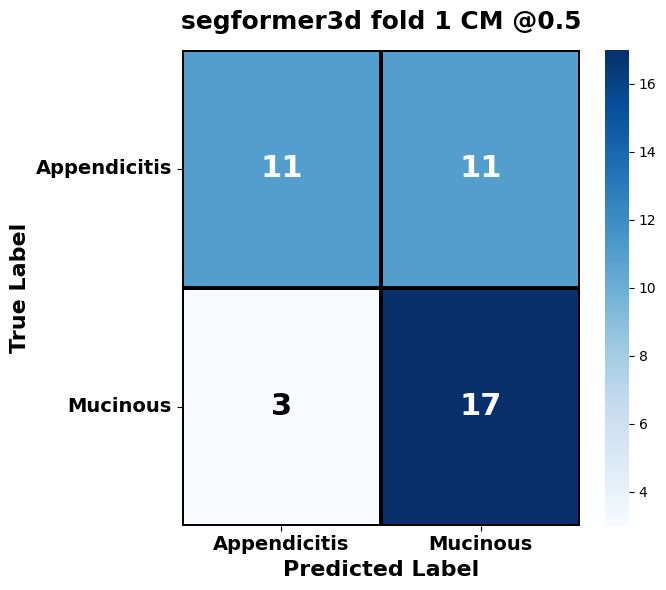

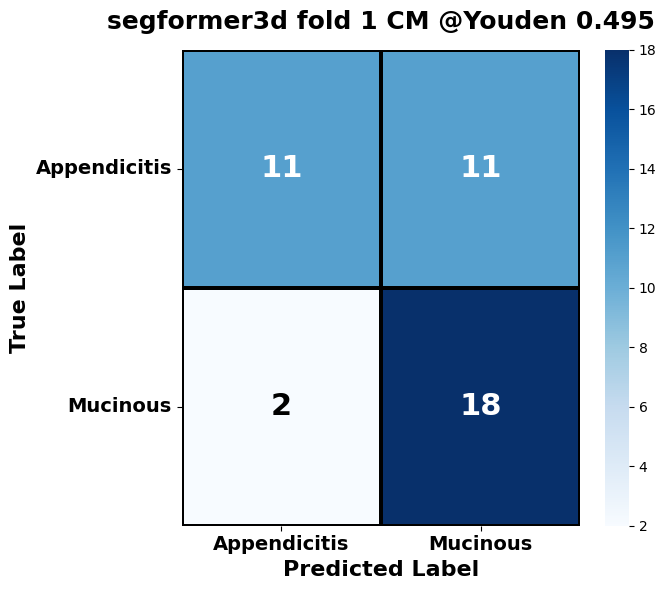

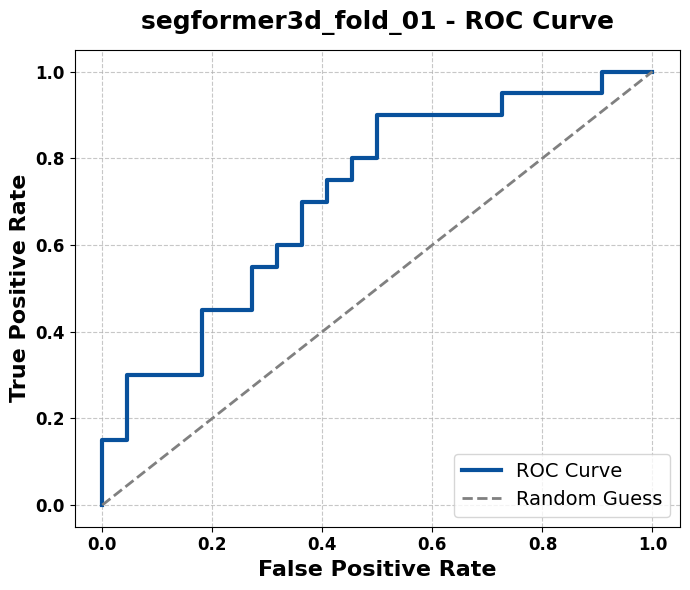

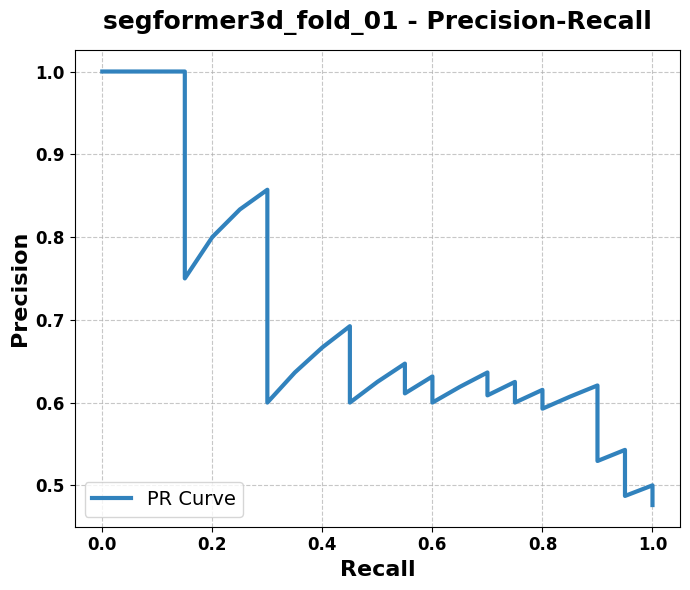

FOLD 2/5
Train class counts:
label_name
Appendisit    86
Musinoz       80
Name: count, dtype: int64
Val class counts:
label_name
Appendisit    23
Musinoz       20
Name: count, dtype: int64

--------------------------------------------------------------------------------
Running model: segformer3d | fold 2
--------------------------------------------------------------------------------


train:   0%|          | 0/21 [00:00<?, ?it/s]

eval:   0%|          | 0/6 [00:00<?, ?it/s]

[segformer3d | fold 2 | epoch 001] train_loss=0.2589 val_loss=0.1729 val_auc=0.5739 val_acc=0.4884 val_f1=0.5217


train:   0%|          | 0/21 [00:00<?, ?it/s]

...

[segformer3d | fold 2 | epoch 055] train_loss=0.1040 val_loss=0.4898 val_auc=0.6370 val_acc=0.5814 val_f1=0.6538


train:   0%|          | 0/21 [00:00<?, ?it/s]

eval:   0%|          | 0/6 [00:00<?, ?it/s]

[segformer3d | fold 2 | epoch 056] train_loss=0.1030 val_loss=0.4977 val_auc=0.6217 val_acc=0.6512 val_f1=0.6939
Early stopping: epoch=56, best_epoch=36, best_score=0.6957


eval:   0%|          | 0/6 [00:00<?, ?it/s]

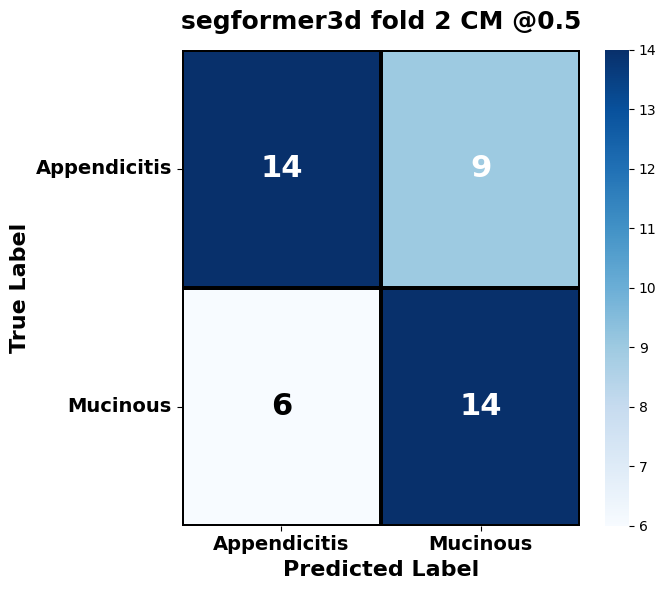

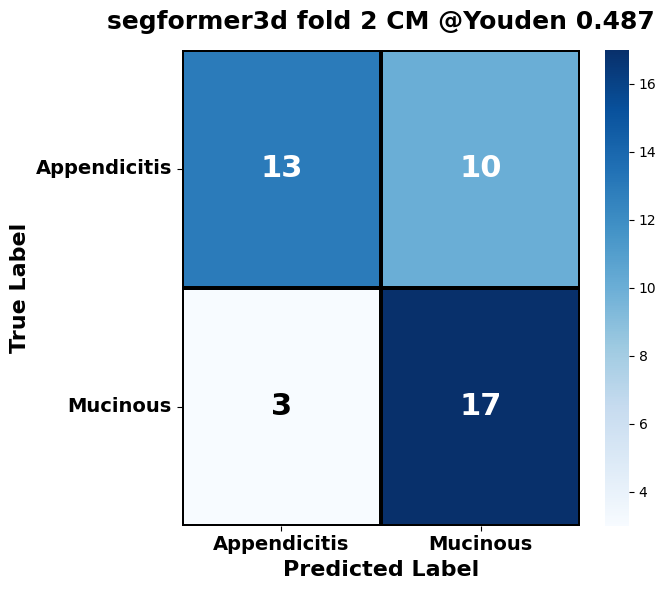

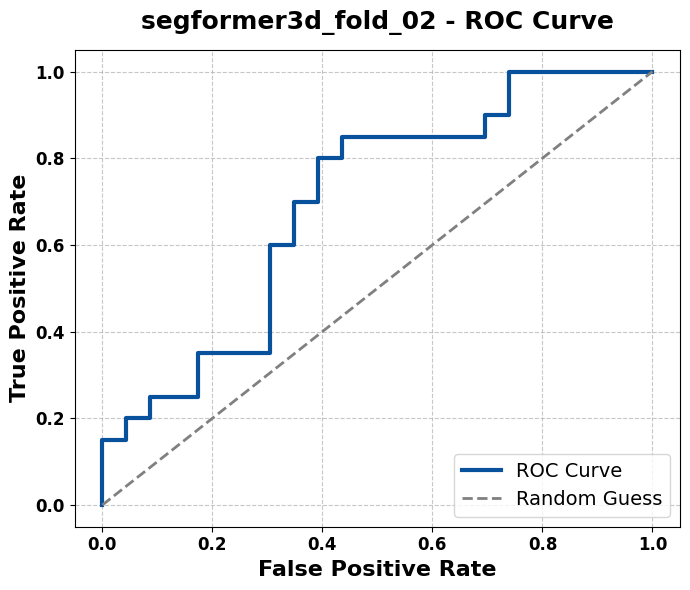

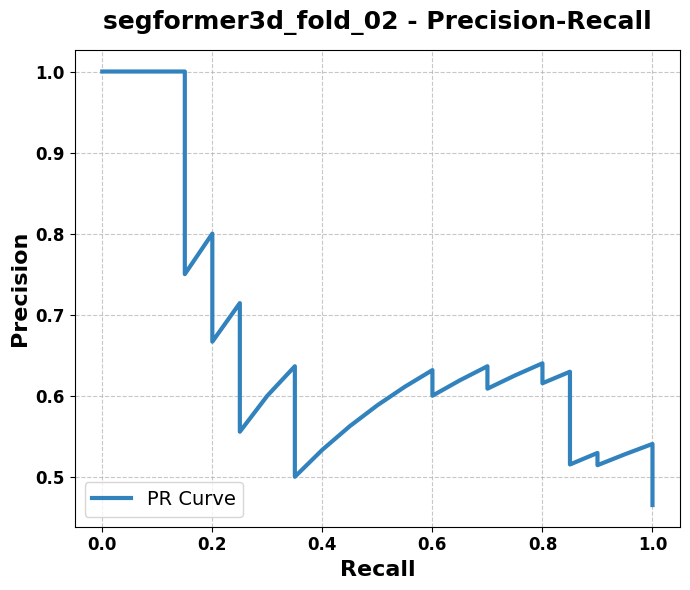

FOLD 3/5
Train class counts:
label_name
Appendisit    86
Musinoz       80
Name: count, dtype: int64
Val class counts:
label_name
Appendisit    22
Musinoz       19
Name: count, dtype: int64

--------------------------------------------------------------------------------
Running model: segformer3d | fold 3
--------------------------------------------------------------------------------


train:   0%|          | 0/21 [00:00<?, ?it/s]

eval:   0%|          | 0/6 [00:00<?, ?it/s]

[segformer3d | fold 3 | epoch 001] train_loss=0.2545 val_loss=0.1919 val_auc=0.5096 val_acc=0.5122 val_f1=0.0000


train:   0%|          | 0/21 [00:00<?, ?it/s]

...

[segformer3d | fold 3 | epoch 065] train_loss=0.0915 val_loss=0.4642 val_auc=0.5885 val_acc=0.6341 val_f1=0.6341


train:   0%|          | 0/21 [00:00<?, ?it/s]

eval:   0%|          | 0/6 [00:00<?, ?it/s]

[segformer3d | fold 3 | epoch 066] train_loss=0.0962 val_loss=0.4702 val_auc=0.5933 val_acc=0.6098 val_f1=0.6000
Early stopping: epoch=66, best_epoch=46, best_score=0.5981


eval:   0%|          | 0/6 [00:00<?, ?it/s]

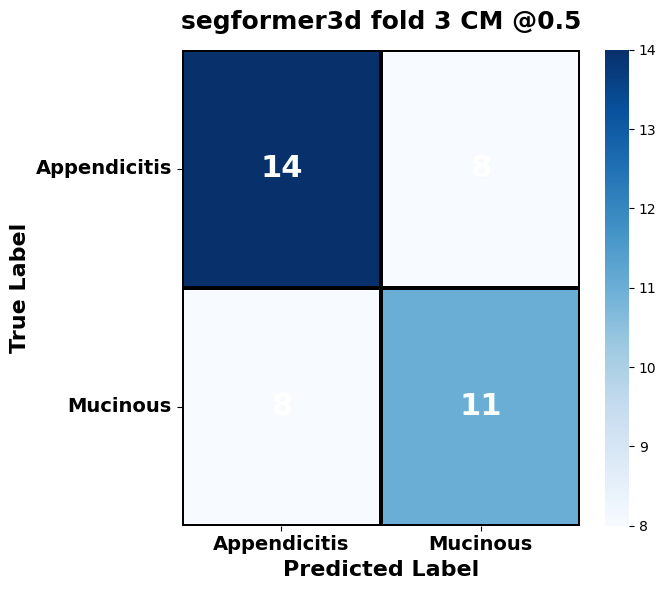

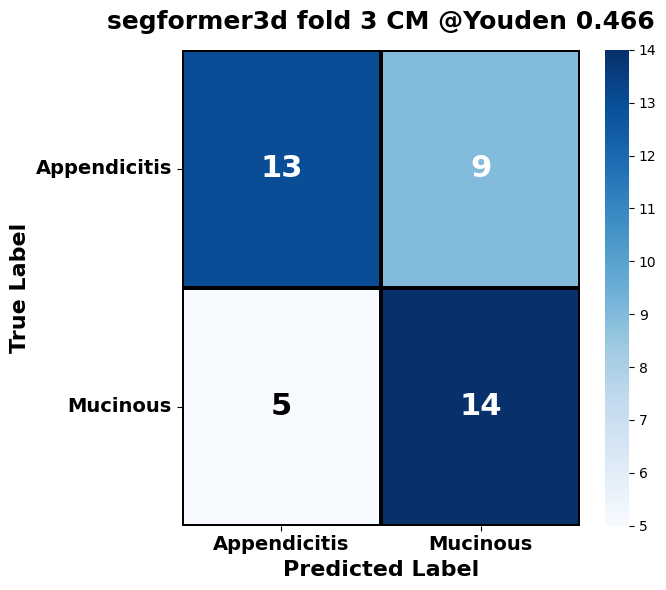

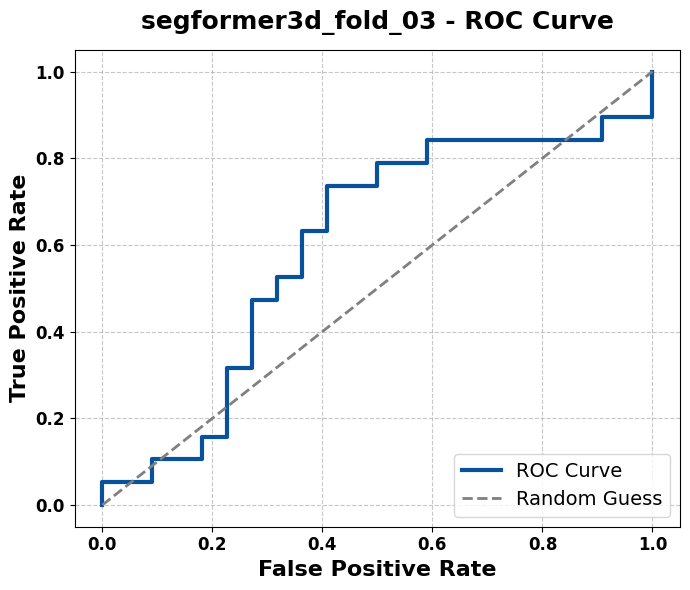

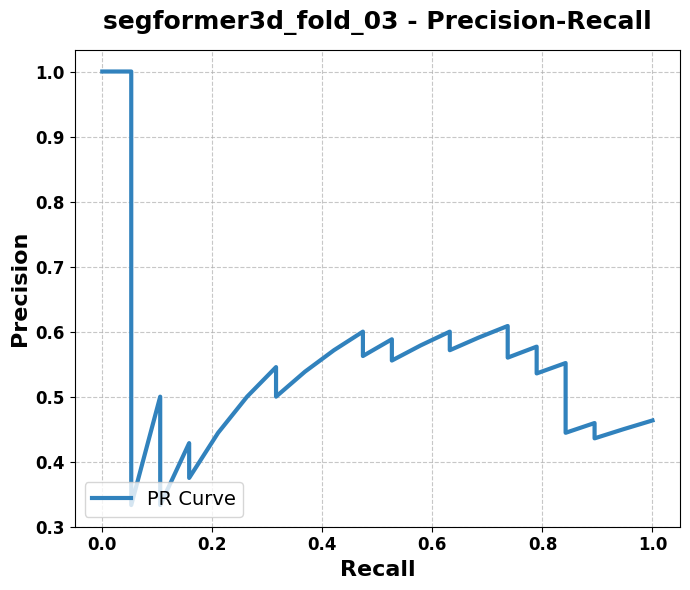

FOLD 4/5
Train class counts:
label_name
Appendisit    88
Musinoz       79
Name: count, dtype: int64
Val class counts:
label_name
Appendisit    21
Musinoz       21
Name: count, dtype: int64

--------------------------------------------------------------------------------
Running model: segformer3d | fold 4
--------------------------------------------------------------------------------


train:   0%|          | 0/21 [00:00<?, ?it/s]

eval:   0%|          | 0/6 [00:00<?, ?it/s]

[segformer3d | fold 4 | epoch 001] train_loss=0.3042 val_loss=0.1660 val_auc=0.6145 val_acc=0.5000 val_f1=0.6667


train:   0%|          | 0/21 [00:00<?, ?it/s]

...

[segformer3d | fold 4 | epoch 058] train_loss=0.1097 val_loss=0.1583 val_auc=0.8254 val_acc=0.7143 val_f1=0.6842


train:   0%|          | 0/21 [00:00<?, ?it/s]

eval:   0%|          | 0/6 [00:00<?, ?it/s]

[segformer3d | fold 4 | epoch 059] train_loss=0.1165 val_loss=0.1814 val_auc=0.8027 val_acc=0.7381 val_f1=0.7027
Early stopping: epoch=59, best_epoch=39, best_score=0.8458


eval:   0%|          | 0/6 [00:00<?, ?it/s]

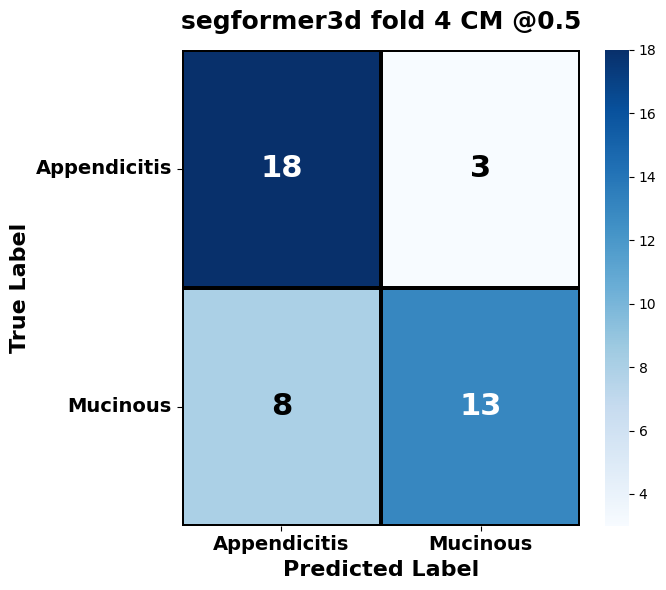

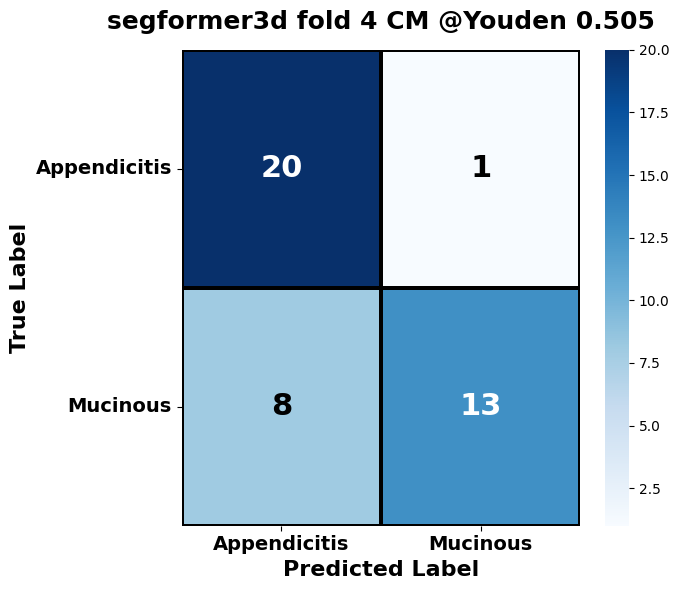

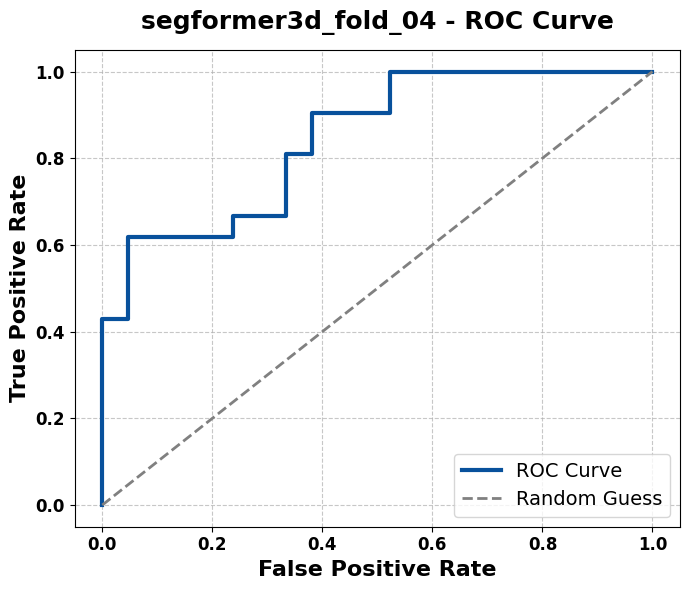

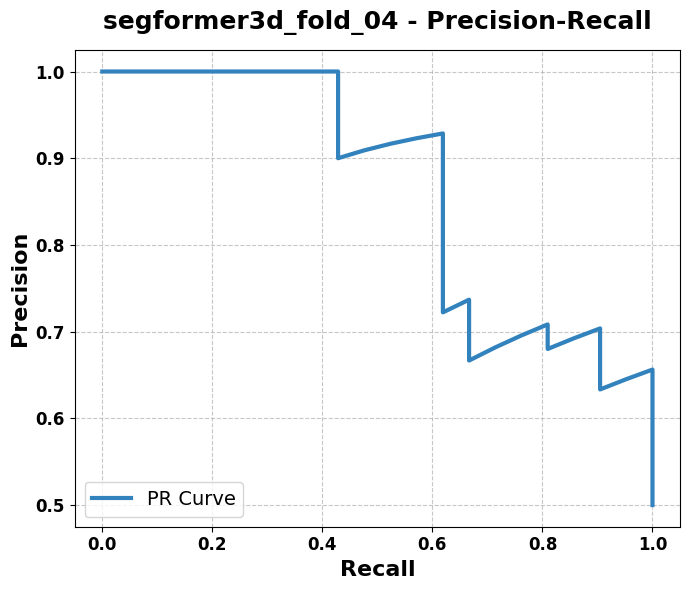

FOLD 5/5
Train class counts:
label_name
Appendisit    87
Musinoz       79
Name: count, dtype: int64
Val class counts:
label_name
Appendisit    21
Musinoz       20
Name: count, dtype: int64

--------------------------------------------------------------------------------
Running model: segformer3d | fold 5
--------------------------------------------------------------------------------


train:   0%|          | 0/21 [00:00<?, ?it/s]

eval:   0%|          | 0/6 [00:00<?, ?it/s]

[segformer3d | fold 5 | epoch 001] train_loss=0.2365 val_loss=0.1426 val_auc=0.8905 val_acc=0.7805 val_f1=0.7273


train:   0%|          | 0/21 [00:00<?, ?it/s]

...

[segformer3d | fold 5 | epoch 020] train_loss=0.1646 val_loss=0.1603 val_auc=0.7000 val_acc=0.6585 val_f1=0.6111


train:   0%|          | 0/21 [00:00<?, ?it/s]

eval:   0%|          | 0/6 [00:00<?, ?it/s]

[segformer3d | fold 5 | epoch 021] train_loss=0.1639 val_loss=0.1447 val_auc=0.8714 val_acc=0.6829 val_f1=0.5185
Early stopping: epoch=21, best_epoch=1, best_score=0.8905


eval:   0%|          | 0/6 [00:00<?, ?it/s]

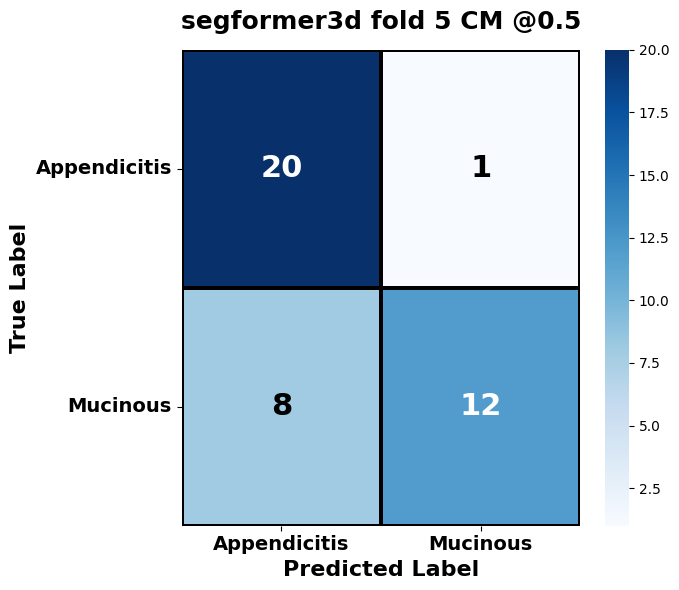

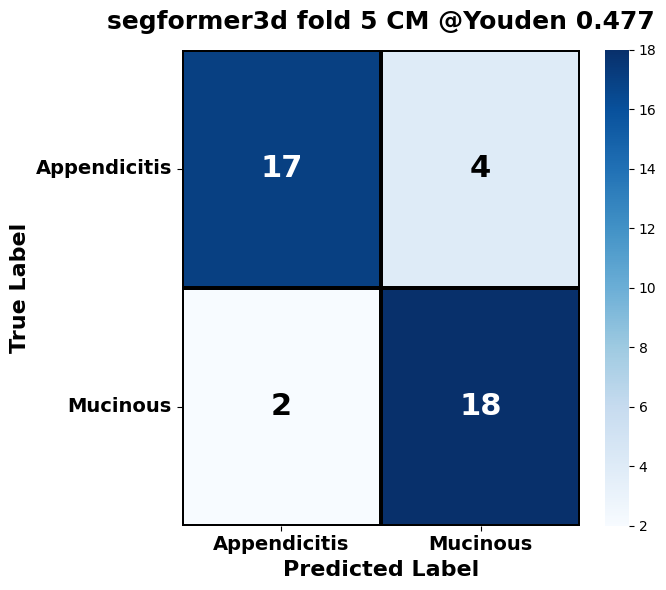

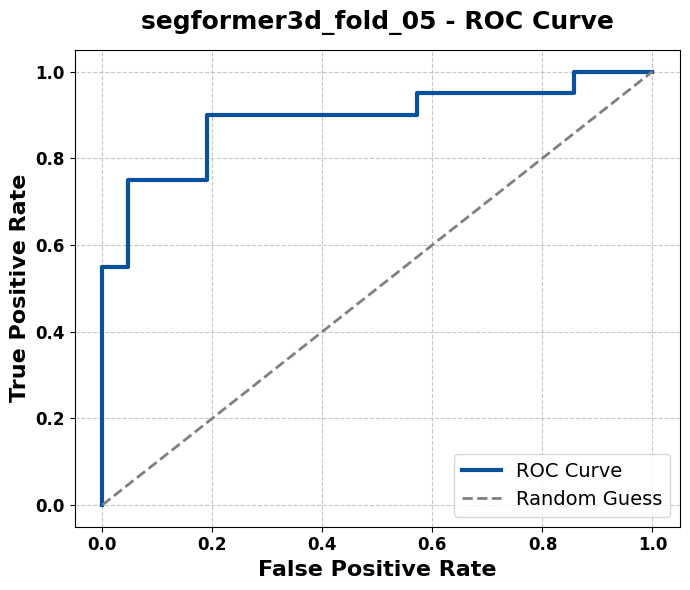

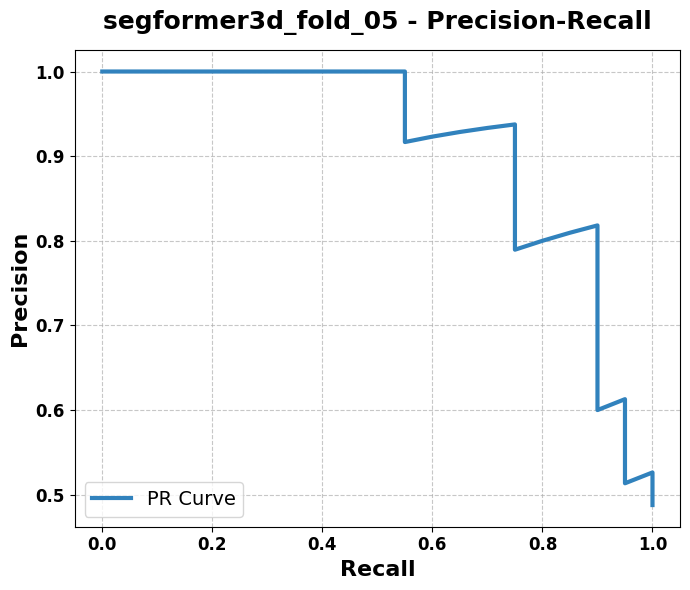

,threshold_name,threshold,auc_roc,auc_pr,accuracy,balanced_accuracy,precision,recall_sensitivity,specificity,f1,tn,fp,fn,tp,fold,model_name,best_epoch,best_score
0,0.5,0.500000,0.711364,0.707797,0.666667,0.675000,0.607143,0.850000,0.500000,0.708333,11,11,3,17,1,segformer3d,16,0.711364
1,youden,0.494559,0.711364,0.707797,0.690476,0.700000,0.620690,0.900000,0.500000,0.734694,11,11,2,18,1,segformer3d,16,0.711364
2,0.5,0.500000,0.695652,0.671259,0.651163,0.654348,0.608696,0.700000,0.608696,0.651163,14,9,6,14,2,segformer3d,36,0.695652
3,youden,0.487207,0.695652,0.671259,0.697674,0.707609,0.629630,0.850000,0.565217,0.723404,13,10,3,17,2,segformer3d,36,0.695652
4,0.5,0.500000,0.598086,0.557719,0.609756,0.607656,0.578947,0.578947,0.636364,0.578947,14,8,8,11,3,segformer3d,46,0.598086


,patient_id,h5_path,label,prob_mucinous,pred_0p5,pred_youden,fold,model_name,youden_threshold
0,akdikemn_mert,/home/zera/Downloads/Appendiks varyasyon3 DS-2...,0,0.606549,1,1,1,segformer3d,0.494559
1,aktas_mehmet,/home/zera/Downloads/Appendiks varyasyon3 DS-2...,0,0.569356,1,1,1,segformer3d,0.494559
2,altin_aynur,/home/zera/Downloads/Appendiks varyasyon3 DS-2...,0,0.579069,1,1,1,segformer3d,0.494559
3,altin_muhammed_talha,/home/zera/Downloads/Appendiks varyasyon3 DS-2...,0,0.586351,1,1,1,segformer3d,0.494559
4,aydogmus_neslihan,/home/zera/Downloads/Appendiks varyasyon3 DS-2...,0,0.517896,1,1,1,segformer3d,0.494559


In [12]:
# ============================================================
# 12) Data Leakage Kontrollü Data Splitting & CV (Ortak Klasörden Okuma)
# ============================================================

def run_5fold_experiment(df, config):
    output_dir = Path(config["output_dir"])
    output_dir.mkdir(parents=True, exist_ok=True)
    
    # DATAS klasörünü kontrol et
    DATAS_DIR = Path('/home/zera/Downloads/Appendiks varyasyon3 DS-20260713T105239Z-2-001/Appendiks varyasyon3 DS/segformer/datas')
    
    if (DATAS_DIR / "external_test_set.csv").exists():
        print(f"Ortak veriseti dosyaları (Stratified) kullanılıyor: {DATAS_DIR}")
        test_df = pd.read_csv(DATAS_DIR / "external_test_set.csv")
    else:
        raise FileNotFoundError(f"Lütfen önce generate_master_splits.py çalıştırıp datas klasörünü oluşturun!")
        
    split_dir = output_dir / "splits"
    split_dir.mkdir(parents=True, exist_ok=True)
    test_df.to_csv(split_dir / "external_test_set.csv", index=False)

    print("=" * 80)
    print("Dataset Loading Completed")
    print(f"Total dataset: {len(df)} patients/samples")
    print(f"External Test: {len(test_df)}")
    print("=" * 80)

    all_metrics = []
    all_predictions = []
    all_history = []

    fold_list = range(1, config["n_splits"]+1)
    if config["limit_folds"] is not None:
        fold_list = list(fold_list)[:int(config["limit_folds"])]

    for fold_idx in fold_list:
        print("=" * 80)
        print(f"FOLD {fold_idx}/{config['n_splits']}")
        print("=" * 80)

        train_df = pd.read_csv(DATAS_DIR / f"fold_{fold_idx}_train.csv")
        val_df = pd.read_csv(DATAS_DIR / f"fold_{fold_idx}_val.csv")



        print("Train class counts:")
        print(train_df["label_name"].value_counts())
        print("Val class counts:")
        print(val_df["label_name"].value_counts())

        train_df.to_csv(split_dir / f"fold_{fold_idx:02d}_train.csv", index=False)
        val_df.to_csv(split_dir / f"fold_{fold_idx:02d}_val.csv", index=False)

        for model_name in config["models_to_run"]:
            print("\n" + "-" * 80)
            print(f"Running model: {model_name} | fold {fold_idx}")
            print("-" * 80)

            metrics_df, pred_df, history_df = run_one_fold_model(
                train_df=train_df,
                val_df=val_df,
                fold_idx=fold_idx,
                model_name=model_name,
                config=config,
                output_dir=output_dir,
            )
            all_metrics.append(metrics_df)
            all_predictions.append(pred_df)
            all_history.append(history_df)

    all_metrics_df = pd.concat(all_metrics, ignore_index=True)
    all_predictions_df = pd.concat(all_predictions, ignore_index=True)
    all_history_df = pd.concat(all_history, ignore_index=True)

    all_metrics_df.to_csv(output_dir / "all_fold_metrics.csv", index=False)
    all_predictions_df.to_csv(output_dir / "all_oof_predictions.csv", index=False)
    all_history_df.to_csv(output_dir / "all_training_history.csv", index=False)

    return all_metrics_df, all_predictions_df, all_history_df


all_metrics_df, all_predictions_df, all_history_df = run_5fold_experiment(manifest_df, CONFIG)

display(all_metrics_df.head())
display(all_predictions_df.head())


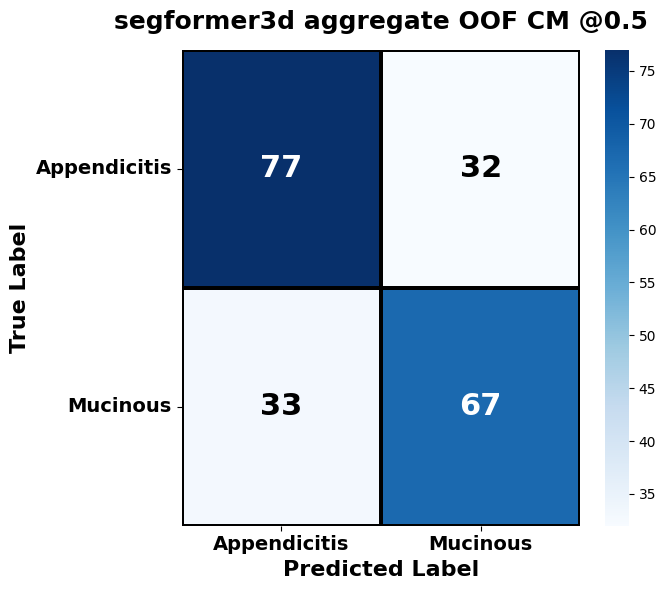

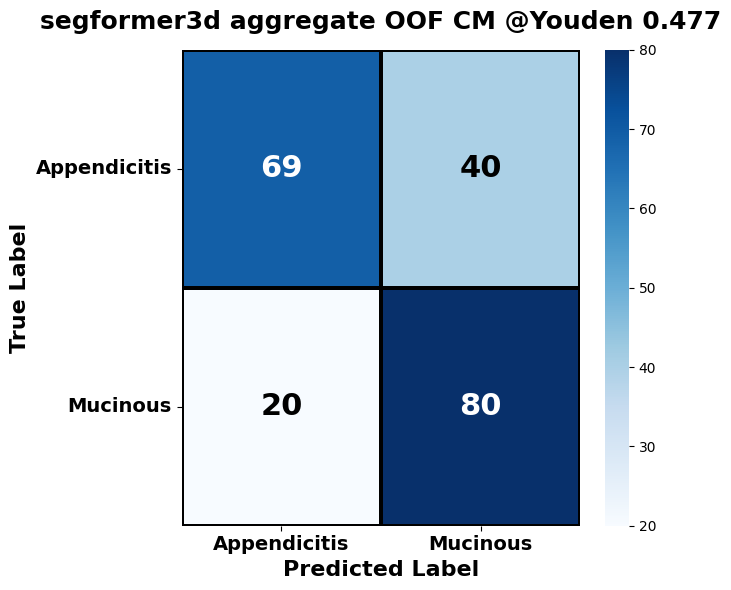

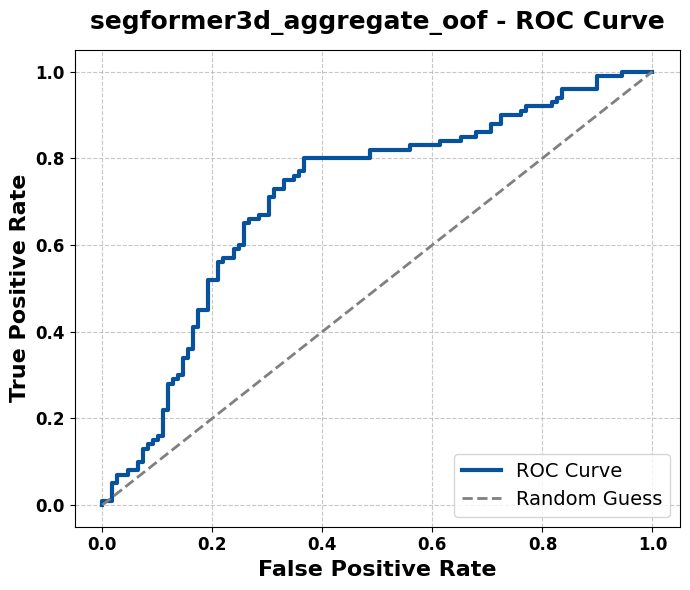

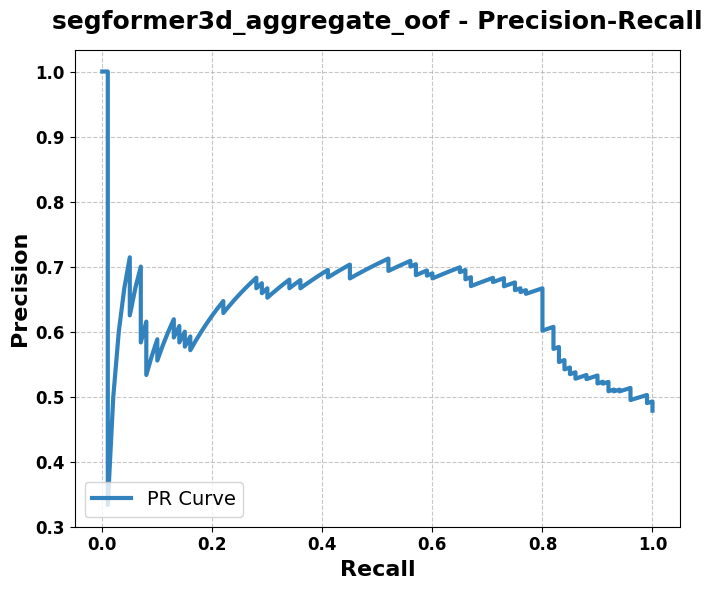

,model_name,threshold_name,threshold,auc_roc,auc_pr,accuracy,balanced_accuracy,precision,recall_sensitivity,specificity,f1,tn,fp,fn,tp
0,segformer3d,0.5,0.500000,0.710367,0.641771,0.688995,0.688211,0.676768,0.67,0.706422,0.673367,77,32,33,67
1,segformer3d,youden,0.477176,0.710367,0.641771,0.712919,0.716514,0.666667,0.80,0.633028,0.727273,69,40,20,80


In [13]:
# ============================================================
# 13) Model bazında aggregate OOF metrics + confusion matrix
# ============================================================

def aggregate_oof_results(all_predictions_df, output_dir, threshold=0.5):
    output_dir = Path(output_dir)
    rows = []

    for model_name, g in all_predictions_df.groupby("model_name"):
        y_true = g["label"].values
        y_prob = g["prob_mucinous"].values

        metrics_05, cm_05, y_pred_05 = compute_binary_metrics(y_true, y_prob, threshold=threshold)
        youden_thr = find_youden_threshold(y_true, y_prob)
        metrics_youden, cm_youden, y_pred_youden = compute_binary_metrics(y_true, y_prob, threshold=youden_thr)

        model_dir = output_dir / model_name / "aggregate_oof"
        model_dir.mkdir(parents=True, exist_ok=True)

        g2 = g.copy()
        g2["pred_0p5_aggregate"] = y_pred_05
        g2["pred_youden_aggregate"] = y_pred_youden
        g2["aggregate_youden_threshold"] = youden_thr
        g2.to_csv(model_dir / "oof_predictions.csv", index=False)

        pd.DataFrame(cm_05, index=["true_appendicitis","true_mucinous"], columns=["pred_appendicitis","pred_mucinous"]).to_csv(model_dir / "aggregate_confusion_matrix_0p5.csv")
        pd.DataFrame(cm_youden, index=["true_appendicitis","true_mucinous"], columns=["pred_appendicitis","pred_mucinous"]).to_csv(model_dir / "aggregate_confusion_matrix_youden.csv")

        plot_confusion_matrix(cm_05, f"{model_name} aggregate OOF CM @0.5", save_path=model_dir / "aggregate_confusion_matrix_0p5.png")
        plot_confusion_matrix(cm_youden, f"{model_name} aggregate OOF CM @Youden {youden_thr:.3f}", save_path=model_dir / "aggregate_confusion_matrix_youden.png")

        plot_roc_pr(y_true, y_prob, title_prefix=f"{model_name}_aggregate_oof", save_dir=model_dir)

        row_05 = {"model_name": model_name, "threshold_name": "0.5", **metrics_05}
        row_youden = {"model_name": model_name, "threshold_name": "youden", **metrics_youden}
        rows.extend([row_05, row_youden])

    summary = pd.DataFrame(rows)
    summary.to_csv(output_dir / "aggregate_oof_metrics_summary.csv", index=False)

    return summary


aggregate_summary = aggregate_oof_results(all_predictions_df, OUTPUT_DIR, threshold=CONFIG["default_threshold"])
display(aggregate_summary)


In [14]:
# ============================================================
# 15) Fold metriklerinin ortalama ± std özeti
# ============================================================

def summarize_fold_metrics(all_metrics_df):
    m = all_metrics_df[all_metrics_df["threshold_name"] == "0.5"].copy()

    metric_cols = [
        "auc_roc",
        "auc_pr",
        "accuracy",
        "balanced_accuracy",
        "precision",
        "recall_sensitivity",
        "specificity",
        "f1",
    ]

    rows = []
    for model_name, g in m.groupby("model_name"):
        row = {"model_name": model_name}
        for col in metric_cols:
            row[f"{col}_mean"] = g[col].mean()
            row[f"{col}_std"] = g[col].std()
        rows.append(row)

    out = pd.DataFrame(rows)
    return out


fold_summary = summarize_fold_metrics(all_metrics_df)
fold_summary.to_csv(OUTPUT_DIR / "fold_metrics_mean_std_0p5.csv", index=False)
display(fold_summary)


,model_name,auc_roc_mean,auc_roc_std,auc_pr_mean,auc_pr_std,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,precision_mean,precision_std,recall_sensitivity_mean,recall_sensitivity_std,specificity_mean,specificity_std,f1_mean,f1_std
0,segformer3d,0.748277,0.118766,0.743558,0.146099,0.689234,0.068902,0.690258,0.067116,0.706073,0.153173,0.669599,0.110777,0.710917,0.187203,0.673684,0.059993


In [15]:
# ============================================================
# 16) Yanlış sınıflanan hastalar listesi
# ============================================================

def export_misclassified(all_predictions_df, output_dir, threshold=0.5):
    output_dir = Path(output_dir)
    rows = []

    for model_name, g in all_predictions_df.groupby("model_name"):
        y_prob = g["prob_mucinous"].values
        pred = (y_prob >= threshold).astype(int)

        tmp = g.copy()
        tmp["pred"] = pred
        tmp["correct"] = tmp["pred"] == tmp["label"]

        errors = tmp[~tmp["correct"]].copy()
        errors.to_csv(output_dir / model_name / "aggregate_oof" / "misclassified_0p5.csv", index=False)

        rows.append(errors)

    if rows:
        all_errors = pd.concat(rows, ignore_index=True)
        all_errors.to_csv(output_dir / "all_misclassified_0p5.csv", index=False)
        return all_errors

    return pd.DataFrame()


all_errors = export_misclassified(all_predictions_df, OUTPUT_DIR, threshold=CONFIG["default_threshold"])
display(all_errors.head(20))
print("Toplam yanlış sınıflama satırı:", len(all_errors))


,patient_id,h5_path,label,prob_mucinous,pred_0p5,pred_youden,fold,model_name,youden_threshold,pred,correct
0,akdikemn_mert,/home/zera/Downloads/Appendiks varyasyon3 DS-2...,0,0.606549,1,1,1,segformer3d,0.494559,1,False
1,aktas_mehmet,/home/zera/Downloads/Appendiks varyasyon3 DS-2...,0,0.569356,1,1,1,segformer3d,0.494559,1,False
2,altin_aynur,/home/zera/Downloads/Appendiks varyasyon3 DS-2...,0,0.579069,1,1,1,segformer3d,0.494559,1,False
3,altin_muhammed_talha,/home/zera/Downloads/Appendiks varyasyon3 DS-2...,0,0.586351,1,1,1,segformer3d,0.494559,1,False
4,aydogmus_neslihan,/home/zera/Downloads/Appendiks varyasyon3 DS-2...,0,0.517896,1,1,1,segformer3d,0.494559,1,False
5,colak_mustafa_resit,/home/zera/Downloads/Appendiks varyasyon3 DS-2...,0,0.528190,1,1,1,segformer3d,0.494559,1,False
6,erdogan_mehmet,/home/zera/Downloads/Appendiks varyasyon3 DS-2...,0,0.580332,1,1,1,segformer3d,0.494559,1,False
7,gorgulu_murat,/home/zera/Downloads/Appendiks varyasyon3 DS-2...,0,0.552752,1,1,1,segformer3d,0.494559,1,False
8,irmak_unek_fatma2,/home/zera/Downloads/Appendiks varyasyon3 DS-2...,0,0.515217,1,1,1,segformer3d,0.494559,1,False
9,karaca_elifnur,/home/zera/Downloads/Appendiks varyasyon3 DS-2...,0,0.507977,1,1,1,segformer3d,0.494559,1,False


Toplam yanlış sınıflama satırı: 65


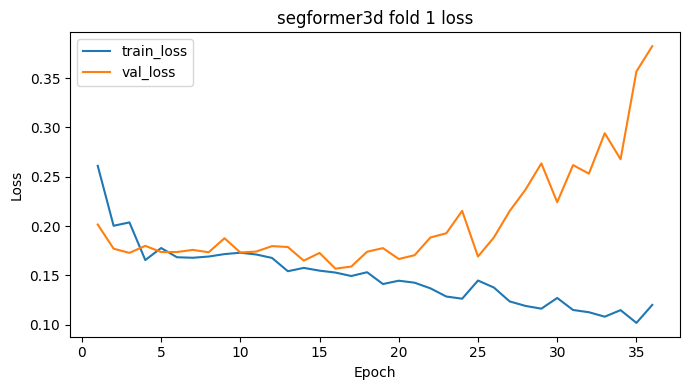

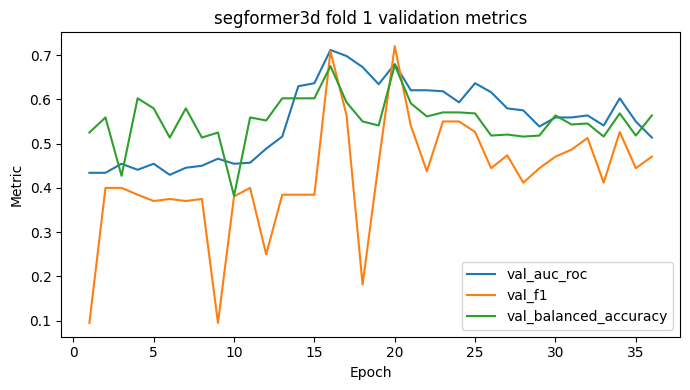

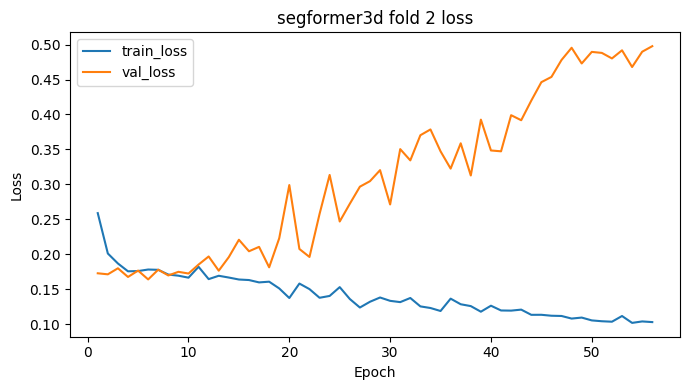

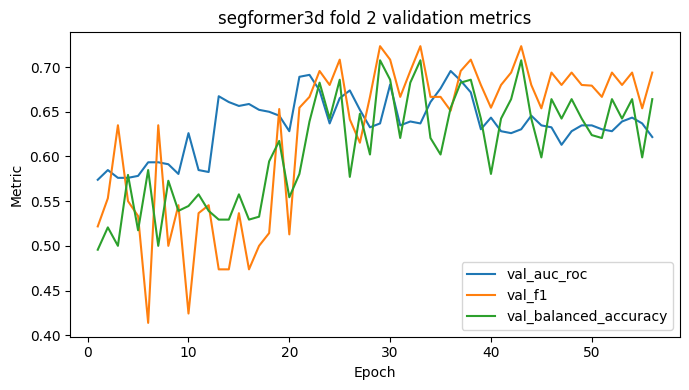

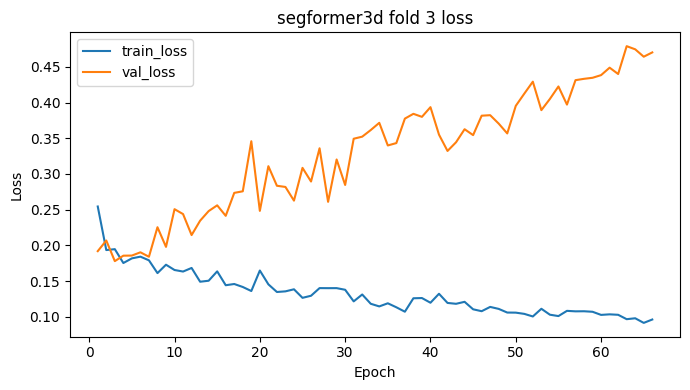

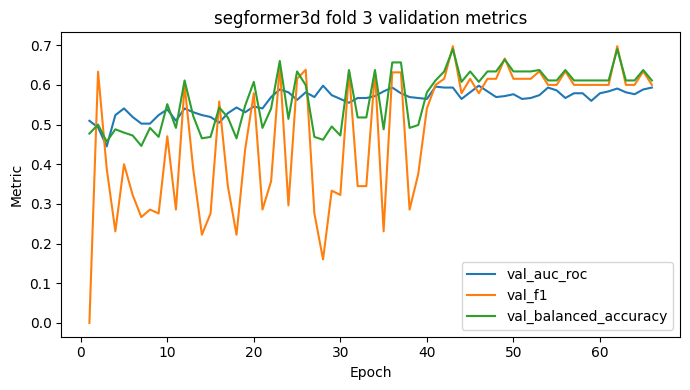

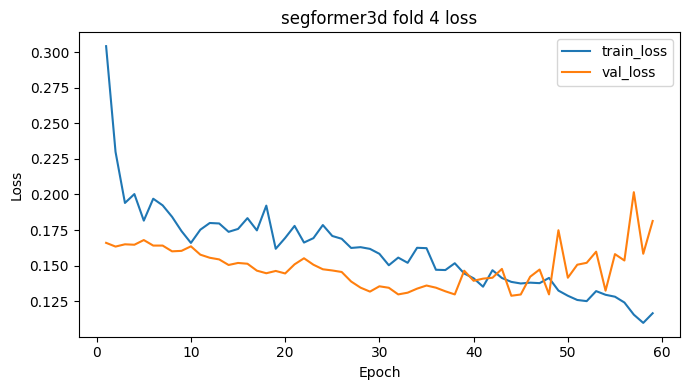

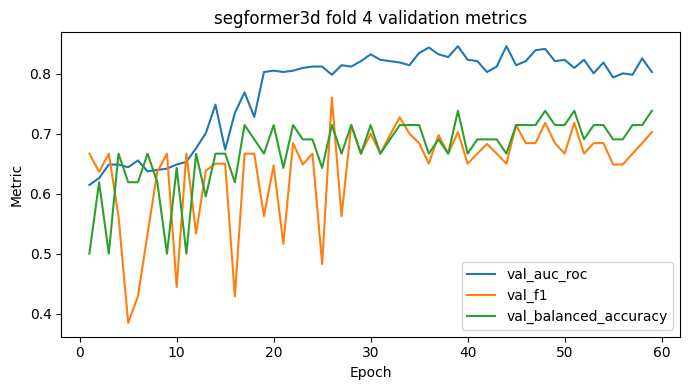

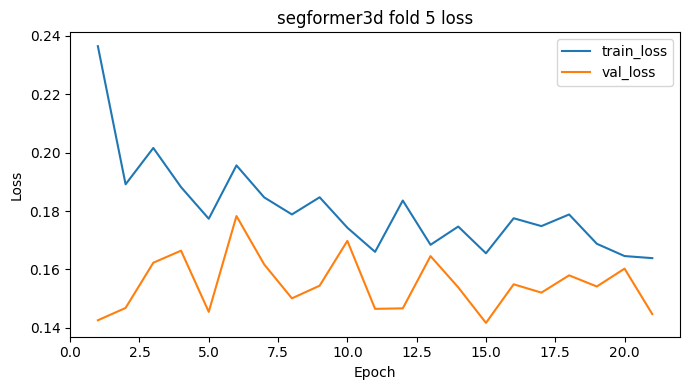

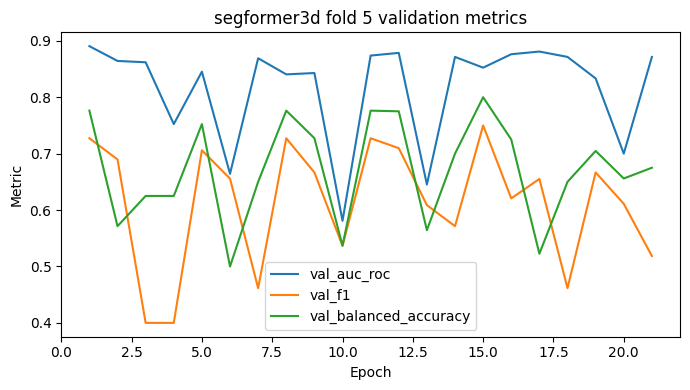

In [16]:
# ============================================================
# 17) Eğitim eğrileri
# ============================================================

def plot_training_curves(all_history_df, output_dir):
    output_dir = Path(output_dir)

    for (model_name, fold), g in all_history_df.groupby(["model_name", "fold"]):
        model_dir = output_dir / model_name / f"fold_{fold:02d}"

        fig, ax = plt.subplots(figsize=(7, 4))
        ax.plot(g["epoch"], g["train_loss"], label="train_loss")
        ax.plot(g["epoch"], g["val_loss"], label="val_loss")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.set_title(f"{model_name} fold {fold} loss")
        ax.legend()
        fig.tight_layout()
        fig.savefig(model_dir / "loss_curve.png", dpi=160, bbox_inches="tight")
        plt.show()

        fig, ax = plt.subplots(figsize=(7, 4))
        ax.plot(g["epoch"], g["val_auc_roc"], label="val_auc_roc")
        ax.plot(g["epoch"], g["val_f1"], label="val_f1")
        ax.plot(g["epoch"], g["val_balanced_accuracy"], label="val_balanced_accuracy")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Metric")
        ax.set_title(f"{model_name} fold {fold} validation metrics")
        ax.legend()
        fig.tight_layout()
        fig.savefig(model_dir / "val_metrics_curve.png", dpi=160, bbox_inches="tight")
        plt.show()


plot_training_curves(all_history_df, OUTPUT_DIR)


## 18. Opsiyonel: Basit 3D Grad-CAM kontrolü

Bu bölüm zorunlu değildir. V03 tek kanallı olduğu için Grad-CAM overlay doğrudan CT native canvas üzerine çizilir.

Notlar:

- Küçük 3D CNN için son konvolüsyon: `block4.conv2`


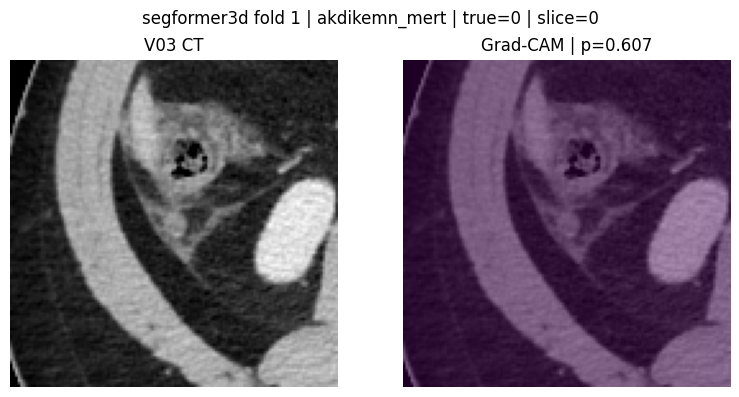

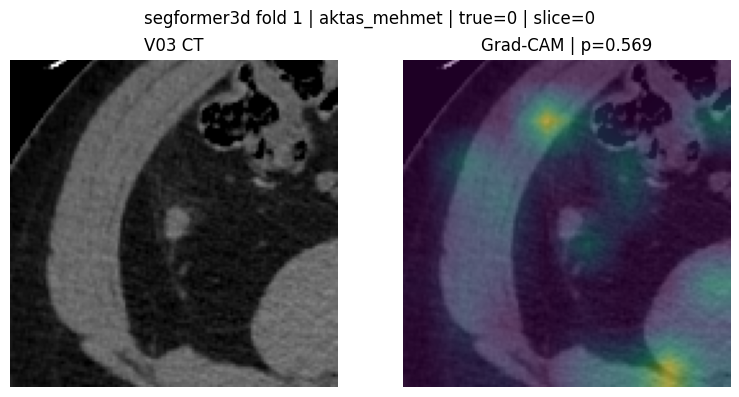

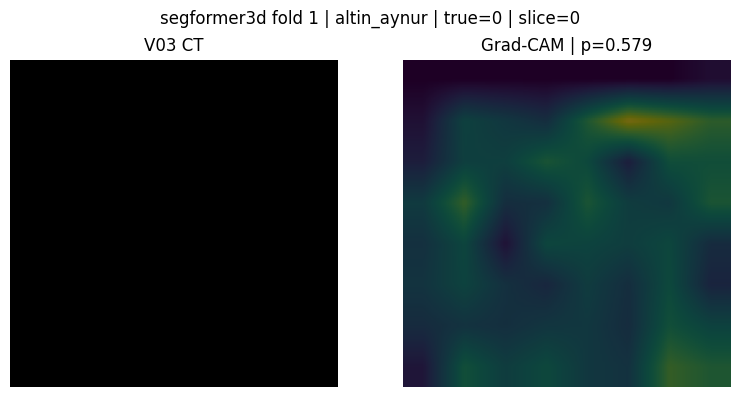

In [17]:
# ============================================================
# 18) Opsiyonel: 3D Grad-CAM
# ============================================================

class GradCAM3D:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None

        self.fwd_handle = target_layer.register_forward_hook(self.forward_hook)
        self.bwd_handle = target_layer.register_full_backward_hook(self.backward_hook)

    def forward_hook(self, module, inp, out):
        self.activations = out.detach()

    def backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def remove(self):
        self.fwd_handle.remove()
        self.bwd_handle.remove()

    def __call__(self, x, class_idx=1):
        self.model.eval()
        logits = self.model(x)
        score = logits[:, class_idx].sum()

        self.model.zero_grad(set_to_none=True)
        score.backward(retain_graph=True)

        weights = self.gradients.mean(dim=(2,3,4), keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = F.relu(cam)

        cam = F.interpolate(cam, size=x.shape[2:], mode="trilinear", align_corners=False)

        cam = cam[0,0].detach().cpu().numpy()
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)
        return cam, logits.detach()


def get_target_layer_for_model(model, model_name):
    if model_name == "segformer3d":
        return model.cbam
    raise ValueError(model_name)
    raise ValueError(model_name)


def run_gradcam_example(model_name="segformer3d", fold_idx=1, n_examples=3):
    fold_dir = OUTPUT_DIR / model_name / f"fold_{fold_idx:02d}"
    ckpt_path = fold_dir / "best_model.pt"
    val_csv = fold_dir / "val_patients.csv"

    if not ckpt_path.exists() or not val_csv.exists():
        print("Checkpoint veya val CSV bulunamadı.")
        return

    val_df = pd.read_csv(val_csv)
    ds = AppendixH5Dataset(val_df, augment=False, config=CONFIG)

    model = build_model(model_name, in_channels=CONFIG["expected_C"], num_classes=2).to(DEVICE)
    ckpt = torch.load(ckpt_path, map_location=DEVICE)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()

    target_layer = get_target_layer_for_model(model, model_name)
    cammer = GradCAM3D(model, target_layer)

    out_dir = fold_dir / "gradcam_examples"
    out_dir.mkdir(parents=True, exist_ok=True)

    for idx in range(min(n_examples, len(ds))):
        item = ds[idx]
        x = item["image"].unsqueeze(0).to(DEVICE)
        label = int(item["label"].item())
        patient_id = item["patient_id"]

        cam, logits = cammer(x, class_idx=1)
        prob = torch.softmax(logits, dim=1)[0,1].item()

        slice_scores = cam.mean(axis=(1,2))
        k = int(np.argmax(slice_scores))

        img = item["image"].numpy()  # [C,D,H,W]
        ct = img[0, k]
        cam_slice = cam[k]

        fig, axes = plt.subplots(1, 2, figsize=(8, 4))
        axes[0].imshow(ct, cmap="gray")
        axes[0].set_title("V03 CT")
        axes[0].axis("off")

        axes[1].imshow(ct, cmap="gray")
        axes[1].imshow(cam_slice, alpha=0.45)
        axes[1].set_title(f"Grad-CAM | p={prob:.3f}")
        axes[1].axis("off")

        plt.suptitle(f"{model_name} fold {fold_idx} | {patient_id} | true={label} | slice={k}")
        fig.tight_layout()
        fig.savefig(out_dir / f"{patient_id}_gradcam.png", dpi=160, bbox_inches="tight")
        plt.show()

    cammer.remove()
    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


# Örnek kullanım:
run_gradcam_example(model_name="segformer3d", fold_idx=1, n_examples=3)


## 19. Çıktıların yorumu

Ana sonuç dosyaları:

```text
all_fold_metrics.csv
aggregate_oof_metrics_summary.csv
fold_metrics_mean_std_0p5.csv
all_oof_predictions.csv
all_misclassified_0p5.csv
```

Model klasörleri:

```text
```

Her model/fold altında:

```text
best_model.pt
train_patients.csv
val_patients.csv
training_history.csv
metrics.csv
val_predictions.csv
confusion_matrix_0p5.png
confusion_matrix_youden.png
roc.png
pr.png
misclassified_0p5.csv
```

V03 sonuçlarını V05 ile karşılaştırırken:

- V03: interpolation yok, native CT crop.
- V05: CT + mask + CT×ROI çok kanallı temsil.

Bu nedenle V03 daha saf görüntü-temelli baseline olarak düşünülmelidir. V05 daha bilgilendirici ama mask kanalından dolayı modele daha fazla lokalizasyon bilgisi verir.


Evaluating segformer3d on External Test Set (Q1 Level)


eval:   0%|          | 0/5 [00:00<?, ?it/s]

eval:   0%|          | 0/5 [00:00<?, ?it/s]

eval:   0%|          | 0/5 [00:00<?, ?it/s]

eval:   0%|          | 0/5 [00:00<?, ?it/s]

eval:   0%|          | 0/5 [00:00<?, ?it/s]

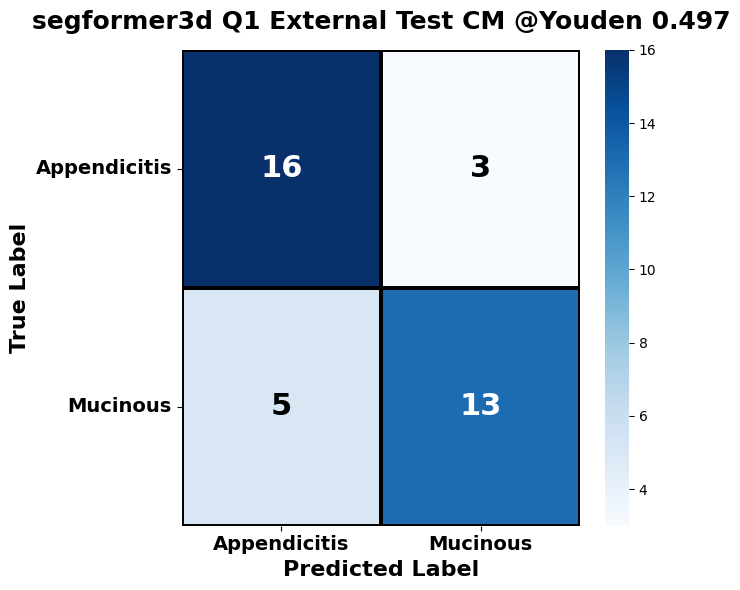

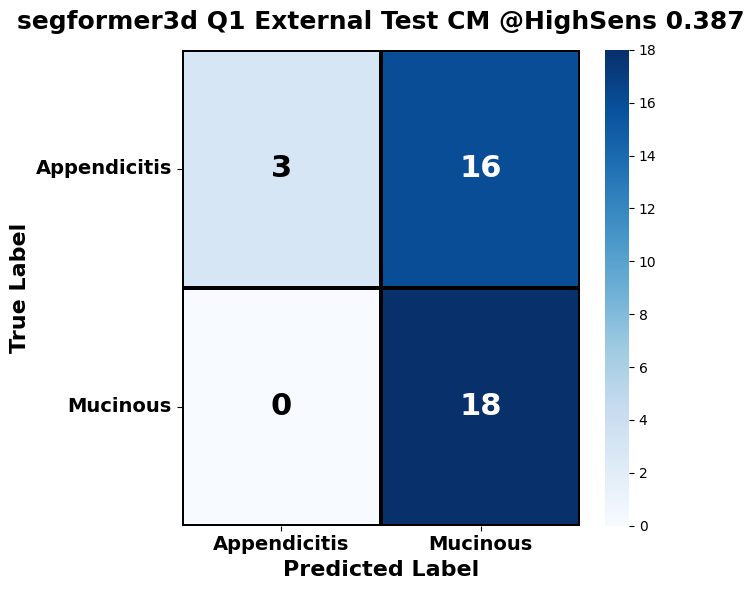

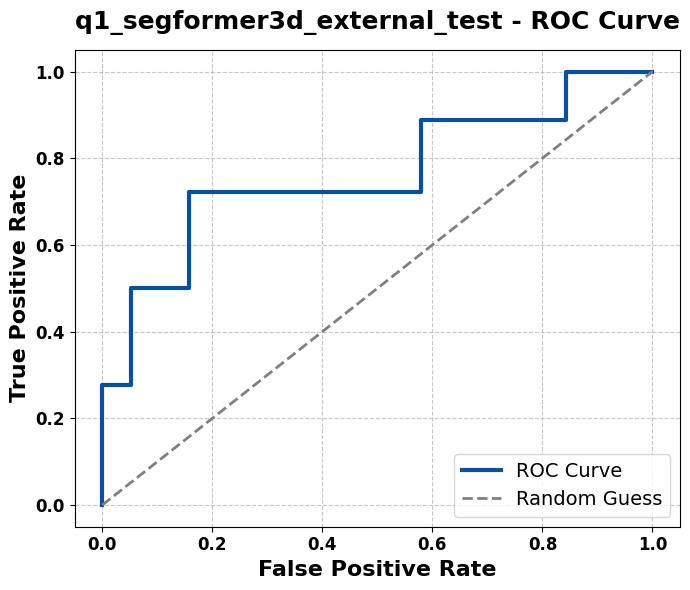

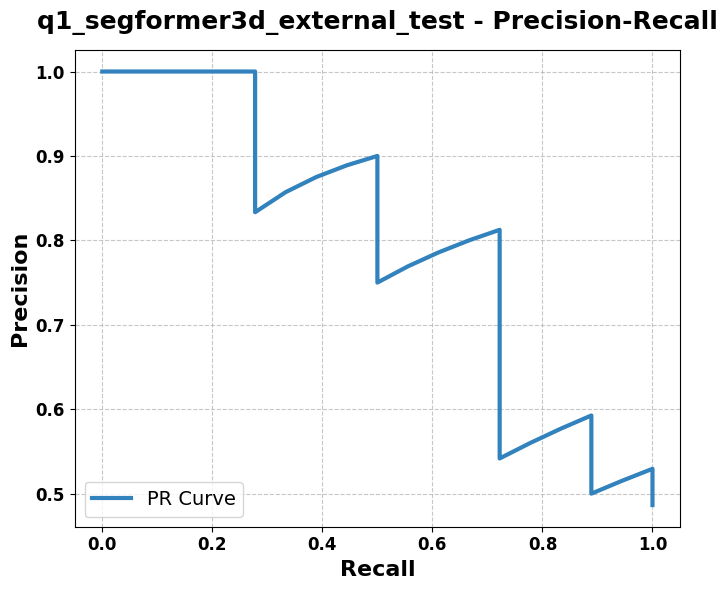


EXTERNAL TEST (ALL FOLDS + ENSEMBLE):
               fold  auc_roc  recall_sensitivity  specificity  accuracy    f1  tp  fp  fn  tn
             Fold 1    0.722               0.611        0.842     0.730 0.688  11   3   7  16
             Fold 2    0.661               0.667        0.632     0.649 0.649  12   7   6  12
             Fold 3    0.716               0.611        0.789     0.703 0.667  11   4   7  15
             Fold 4    0.795               0.722        0.789     0.757 0.743  13   4   5  15
             Fold 5    0.833               0.778        0.789     0.784 0.778  14   4   4  15
    Ensemble (@0.5)    0.763               0.667        0.842     0.757 0.727  12   3   6  16
 Ensemble (@Youden)    0.763               0.722        0.842     0.784 0.765  13   3   5  16
Ensemble (90+ Sens)    0.763               1.000        0.158     0.568 0.692  18  16   0   3


In [18]:
import pandas as pd
import numpy as np
def evaluate_external_test(config, model_name="segformer3d"):
    print("=" * 80)
    print(f"Evaluating {model_name} on External Test Set (Q1 Level)")
    print("=" * 80)
    
    output_dir = Path(config["output_dir"])
    DATAS_DIR = Path('/home/zera/Downloads/Appendiks varyasyon3 DS-20260713T105239Z-2-001/Appendiks varyasyon3 DS/segformer/datas')
    test_csv_path = DATAS_DIR / "external_test_set.csv"
    
    if not test_csv_path.exists():
        print(f"External test set bulunamadı: {test_csv_path}")
        return
        
    test_df = pd.read_csv(test_csv_path)
    test_ds = AppendixH5Dataset(test_df, augment=False, config=config)
    test_loader = DataLoader(
        test_ds, batch_size=config["batch_size"], shuffle=False,
        num_workers=config["num_workers"], pin_memory=torch.cuda.is_available()
    )
    
    all_fold_probs = []
    criterion = nn.CrossEntropyLoss()
    
    fold_metrics_list = []
    yt = test_df["label"].values

    ens_dir = output_dir / model_name / "external_test_q1_evaluation"
    ens_dir.mkdir(parents=True, exist_ok=True)

    def add_q1_metrics(metrics_dict, cm):
        tn, fp, fn, tp = cm.ravel()
        metrics_dict["tp"] = tp; metrics_dict["fp"] = fp
        metrics_dict["fn"] = fn; metrics_dict["tn"] = tn
        metrics_dict["ppv_precision"] = tp / (tp + fp + 1e-8)
        metrics_dict["npv"] = tn / (tn + fn + 1e-8)
        return metrics_dict
    
    for fold_idx in range(1, config["n_splits"] + 1):
        best_path = output_dir / model_name / f"fold_{fold_idx:02d}" / "best_model.pt"
        if not best_path.exists(): continue
            
        model = build_model(model_name=model_name, in_channels=config["expected_C"], num_classes=2).to(DEVICE)
        checkpoint = torch.load(best_path, map_location=DEVICE)
        model.load_state_dict(checkpoint["model_state_dict"])
        model.eval()
        
        _, _, pred_df = evaluate_model(model, test_loader, criterion, DEVICE)
        fold_prob = pred_df["prob_mucinous"].values
        all_fold_probs.append(fold_prob)
        
        opt_thr_fold = find_youden_threshold(yt, fold_prob)
        m_fold, cm_fold, _ = compute_binary_metrics(yt, fold_prob, threshold=opt_thr_fold)
        m_fold = add_q1_metrics(m_fold, cm_fold)
        m_fold['fold'] = f"Fold {fold_idx}"
        m_fold['youden_thr'] = opt_thr_fold
        fold_metrics_list.append(m_fold)
        
        del model
        if torch.cuda.is_available(): torch.cuda.empty_cache()
            
    if not all_fold_probs: return
        
    ens = np.mean(all_fold_probs, axis=0)
    
    # 0.5 metrics
    m_05, cm_05, _ = compute_binary_metrics(yt, ens, threshold=0.5)
    m_05 = add_q1_metrics(m_05, cm_05)
    m_05['fold'] = "Ensemble (@0.5)"
    fold_metrics_list.append(m_05)
    
    # Youden metrics
    youden_thr = find_youden_threshold(yt, ens)
    m_y, cm_y, _ = compute_binary_metrics(yt, ens, threshold=youden_thr)
    m_y = add_q1_metrics(m_y, cm_y)
    m_y['fold'] = "Ensemble (@Youden)"
    m_y['youden_thr'] = youden_thr
    fold_metrics_list.append(m_y)

    # High Sens metrics
    from sklearn.metrics import roc_curve
    fpr, tpr, thrs = roc_curve(yt, ens)
    valid_idx = np.where(tpr >= 0.90)[0]
    high_sens_thr = thrs[valid_idx[0]] if len(valid_idx) > 0 else thrs[-1]
    
    m_sens, cm_sens, _ = compute_binary_metrics(yt, ens, threshold=high_sens_thr)
    m_sens = add_q1_metrics(m_sens, cm_sens)
    m_sens['fold'] = "Ensemble (90+ Sens)"
    m_sens['youden_thr'] = high_sens_thr
    fold_metrics_list.append(m_sens)
    
    df_all_metrics = pd.DataFrame(fold_metrics_list)
    cols = ['fold'] + [c for c in df_all_metrics.columns if c != 'fold']
    df_all_metrics = df_all_metrics[cols]
    df_all_metrics.to_csv(ens_dir / "all_folds_test_metrics.csv", index=False)
    
    plot_confusion_matrix(cm_y, f"{model_name} Q1 External Test CM @Youden {youden_thr:.3f}", save_path=ens_dir / "q1_cm_youden.png")
    plot_confusion_matrix(cm_sens, f"{model_name} Q1 External Test CM @HighSens {high_sens_thr:.3f}", save_path=ens_dir / "q1_cm_highsens.png")
    plot_roc_pr(yt, ens, title_prefix=f"q1_{model_name}_external_test", save_dir=ens_dir)
    
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 1000)
    print("\nEXTERNAL TEST (ALL FOLDS + ENSEMBLE):")
    
    # Dynamically select columns that exist
    display_cols = ['fold', 'auc_roc', 'recall_sensitivity', 'specificity', 'accuracy', 'tp', 'fp', 'fn', 'tn']
    if 'f1_score' in df_all_metrics.columns: display_cols.insert(5, 'f1_score')
    elif 'f1' in df_all_metrics.columns: display_cols.insert(5, 'f1')
        
    display_df = df_all_metrics[display_cols]
    print(display_df.round(3).to_string(index=False))
    
    return df_all_metrics

q1_summary = evaluate_external_test(CONFIG, model_name="segformer3d")
